# ENTSO-E Transparency Platform Data Fetching

This notebook fetches data from the ENTSO-E Transparency Platform API for:
- Day-ahead electricity prices
- Production and consumption data (actual load, forecast load, generation)
- Cross-border flows
- Wind and PV generation forecasts and actuals

All data is converted to UTC and resampled to hourly intervals.

In [1]:
import os
import io
import re
import time
import random
import requests
import gzip
import zipfile
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from pathlib import Path
from tqdm import tqdm
from typing import Optional, List, Dict, Literal, Union
from dotenv import load_dotenv

## Configuration

In [30]:
# Load API key from .env file
load_dotenv()
ENTSOE_API_KEY = os.getenv("ENTSOE_API_KEY")

if not ENTSOE_API_KEY:
    raise ValueError("ENTSOE_API_KEY not found in .env file. Please add it.")

# Base URL for ENTSO-E API
ENTSOE_BASE_URL = "https://web-api.tp.entsoe.eu/api"

# Date range for fetching data
START_DATE = datetime(2021, 10, 1)
END_DATE = datetime(2026, 2, 23)

# Output directories
DATA_DIR = Path("../data")
DAY_AHEAD_PRICES_DIR = DATA_DIR / "day_ahead_electricity_prices"
PRODUCTION_DIR = DATA_DIR / "production_new"
CONSUMPTION_DIR = DATA_DIR / "consumption_new"
WIND_PV_DIR = DATA_DIR / "wind_pv_generation"
CROSS_BORDER_DIR = DATA_DIR / "cross_border_flows"
SCHEDULED_EXCHANGES_DIR = DATA_DIR / "scheduled_exchanges"
REDISPATCHING_COSTS_DIR = DATA_DIR / "redispatching_costs"

# Create directories if they don't exist
for dir_path in [DAY_AHEAD_PRICES_DIR, PRODUCTION_DIR, CONSUMPTION_DIR, WIND_PV_DIR, CROSS_BORDER_DIR, SCHEDULED_EXCHANGES_DIR, REDISPATCHING_COSTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

## EIC Codes and Constants

In [3]:
# Bidding zone / control area EIC codes
BIDDING_ZONES = {
    "DE_LU": "10Y1001A1001A82H",       # Germany-Luxembourg
    "DK_1": "10YDK-1--------W",         # Denmark DK1
    "DK_2": "10YDK-2--------M",         # Denmark DK2
    "DK": "10Y1001A1001A796",           # Denmark (entire)
    "PL": "10YPL-AREA-----S",           # Poland
    "CZ": "10YCZ-CEPS-----N",           # Czech Republic
    "AT": "10YAT-APG------L",           # Austria
    "CH": "10YCH-SWISSGRIDZ",           # Switzerland
    "FR": "10YFR-RTE------C",           # France
    "BE": "10YBE----------2",           # Belgium
    "NL": "10YNL----------L",           # Netherlands
}

# German TSO control area EIC codes
GERMAN_TSO_AREAS = {
    "DE_TenneT": "10YDE-EON------1",     # TenneT
    "DE_50HzT": "10YDE-VE-------2",      # 50Hertz
    "DE_Amprion": "10YDE-RWENET---I",    # Amprion
    "DE_TransnetBW": "10YDE-ENBW-----N", # TransnetBW
}

# PSR Type codes for production types
PSR_TYPES = {
    "B01": "Biomass",
    "B02": "Fossil Brown coal/Lignite",
    "B03": "Fossil Coal-derived gas",
    "B04": "Fossil Gas",
    "B05": "Fossil Hard coal",
    "B06": "Fossil Oil",
    "B07": "Fossil Oil shale",
    "B08": "Fossil Peat",
    "B09": "Geothermal",
    "B10": "Hydro Pumped Storage",
    "B11": "Hydro Run-of-river and poundage",
    "B12": "Hydro Water Reservoir",
    "B13": "Marine",
    "B14": "Nuclear",
    "B15": "Other renewable",
    "B16": "Solar",
    "B17": "Waste",
    "B18": "Wind Offshore",
    "B19": "Wind Onshore",
    "B20": "Other",
    "B25": "Energy storage",
}

# Document types
DOCUMENT_TYPES = {
    "day_ahead_prices": "A44",          # Price document
    "actual_load": "A65",               # System total load
    "load_forecast": "A65",             # System total load (with different process type)
    "generation_forecast": "A71",       # Generation forecast
    "wind_solar_forecast": "A69",       # Wind and solar forecast
    "actual_generation": "A75",         # Actual generation per type
    "installed_capacity": "A68",        # Installed generation capacity aggregated
    "cross_border_flows": "A11",        # Aggregated energy data report (scheduled exchanges)
    "outages_prod": "A77",              # Unavailability of generation units
    "outages_gen": "A80",               # Planned unavailability of generation units   
    "congestion_costs": "A92"           # Congestion management costs
}

DOCUMENT_STATUS = {
    "Active": "A05",
    "Cancelled" : "A09",
    "Withdrawn": "A13",
}

BUSINESS_TYPES = {
    "Planned maintenance": "A53",
    "Forced outage": "A54",
    "Redispatch costs": "A46",
}

# Process types
PROCESS_TYPES = {
    "day_ahead": "A01",
    "intraday": "A40",
    "realised": "A16",
    "current": "A18",
    "year_ahead": "A33",
}

## Base ENTSO-E API Client

In [22]:
class ENTSOEClient:
    """
    Base client for ENTSO-E Transparency Platform API.
    Handles authentication, rate limiting, date chunking, and XML parsing.
    """
    
    def __init__(self, api_key: str, base_url: str = ENTSOE_BASE_URL):
        self.api_key = api_key
        self.base_url = base_url
        self.session = requests.Session()
        
    def _format_datetime(self, dt: datetime) -> str:
        """Format datetime to ENTSO-E API format (yyyyMMddHHmm)."""
        return dt.strftime("%Y%m%d%H%M")
    
    def _random_sleep(self, min_seconds: float = 1.0, max_seconds: float = 3.0):
        """Sleep for a random duration to respect rate limits."""
        sleep_time = random.uniform(min_seconds, max_seconds)
        time.sleep(sleep_time)
    
    def _chunk_date_range(self, start: datetime, end: datetime, max_days: int = 365) -> List[tuple]:
        """
        Split date range into chunks (max 1 year for ENTSO-E API).
        Returns list of (start, end) datetime tuples.
        """
        chunks = []
        current_start = start
        
        while current_start < end:
            current_end = min(current_start + timedelta(days=max_days), end)
            chunks.append((current_start, current_end))
            current_start = current_end
            
        return chunks
    
    def _decode_and_parse(self, content: bytes, encoding: str = "utf-8"):
        head = content[:4]

        if head.startswith(b"PK\x03\x04"):  # ZIP
            z = zipfile.ZipFile(io.BytesIO(content))
            zipped_data = []
            for name in z.namelist():
                if name.lower().endswith(".xml"):
                    zipped_data.append(z.read(name).decode(encoding))
            return zipped_data

        if head.startswith(b"PK\x05\x06"):  # Empty ZIP
            return []

        if content[:2] == b"\x1f\x8b":  # GZIP
            xml_bytes = gzip.decompress(content).decode(encoding)
            return xml_bytes

        # Otherwise assume plain XML (possibly with leading whitespace/BOM)
        xml_bytes = content.lstrip()
        if xml_bytes.startswith(b"<"):
            return xml_bytes.decode(encoding)
        with open("inspect.zip", "wb") as f:
            f.write(content)
        raise ValueError(f"Unknown payload. First bytes: {head!r}")
    
    def _make_request(self, params: dict) -> Optional[str | List[str]]:
        """
        Make a request to the ENTSO-E API with error handling and rate limiting.
        Returns XML response as string or None on failure.
        """
        params["securityToken"] = self.api_key
        
        try:
            response = self.session.get(self.base_url, params=params, timeout=60)
            
            # Handle common HTTP errors
            if response.status_code == 200:
                # Check for API error in XML response
                if "<Reason>" in response.text and "No matching data found" in response.text:
                    return None
                return self._decode_and_parse(response.content)
            elif response.status_code == 400:
                print(f"Bad Request (400): Invalid parameters - {params}")
                return None
            elif response.status_code == 401:
                raise ValueError("Unauthorized (401): Invalid API key")
            elif response.status_code == 403:
                print(f"Forbidden (403): Access denied for this data")
                return None
            elif response.status_code == 404:
                print(f"Not Found (404): No data available for parameters - {params}")
                return None
            elif response.status_code == 409:
                print(f"Conflict (409): Request limit exceeded, waiting...")
                time.sleep(60)  # Wait 1 minute before retry
                return self._make_request(params)
            elif response.status_code == 429:
                print(f"Too Many Requests (429): Rate limit exceeded, waiting...")
                time.sleep(60)
                return self._make_request(params)
            else:
                print(f"HTTP Error {response.status_code} for {params}: {response.text}")
                return None
                
        except requests.exceptions.Timeout:
            print("Request timed out, retrying...")
            time.sleep(5)
            return self._make_request(params)
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            return None
    
    def _parse_xml_to_dataframe(self, xml_text: str, value_type: str = "quantity", business_type_filter: str | None = None) -> pd.DataFrame:
        """
        Parse ENTSO-E XML response to DataFrame.
        Extracts TimeSeries data with begin_date, end_date, and values.
        
        Parameters:
        - xml_text: Raw XML response
        - value_type: Type of value to extract ('quantity', 'price.amount')
        - business_type_filter: Filter by business type

        Returns DataFrame with columns: begin_date, end_date, value, [optional metadata]
        """
        if not xml_text:
            return pd.DataFrame()
       
        # Define namespace
        ns = {
            'gl': 'urn:iec62325.351:tc57wg16:451-6:generationloaddocument:3:0',
            'pub': 'urn:iec62325.351:tc57wg16:451-3:publicationdocument:7:3',
            'tp': 'urn:iec62325.351:tc57wg16:451-3:transmissionnetworkdocument:2:4',
        }

        def find_elem(parent, tag):
            """Find element with or without namespace."""
            if ns:
                elem = parent.find(f'.//{{{ns["ns"]}}}{tag}')
                if elem is None:
                    elem = parent.find(f'.//{tag}')
            else:
                elem = parent.find(f'.//{tag}')
            return elem
    
        def get_text(parent, tag, default=None):
            """Get text content of element."""
            elem = find_elem(parent, tag)
            return elem.text if elem is not None else default
        
        try:
            root = ET.fromstring(xml_text)
        except ET.ParseError as e:
            print(f"XML parsing error: {e}")
            return pd.DataFrame()

        
        # Try to detect namespace from root element
        root_ns = root.tag.split('}')[0].strip('{') if '}' in root.tag else ''

        ns = {'ns': root_ns, "default": root_ns} if root_ns else {}
        
        records = []
        
        # Find all TimeSeries elements
        for ts_ns_key in ['default', 'gl', 'pub', 'tp']:
            if ts_ns_key not in ns:
                continue
            time_series_list = root.findall(f'.//{{{ns[ts_ns_key]}}}TimeSeries')
            if time_series_list:
                break
        else:
            # Fallback: try without namespace
            time_series_list = root.findall('.//TimeSeries')
        
        for ts in time_series_list:
            # Extract metadata
            metadata = {}
            
            # Try to get PSR type
            psr_type_elem = ts.find('.//{*}psrType')
            if psr_type_elem is not None:
                metadata['psr_type'] = psr_type_elem.text
                metadata['psr_type_name'] = PSR_TYPES.get(psr_type_elem.text, psr_type_elem.text)
            
            # Try to get domain/area
            for domain_tag in ['inBiddingZone_Domain.mRID', 'in_Domain.mRID', 'outBiddingZone_Domain.mRID', 'out_Domain.mRID']:
                domain_elem = ts.find(f'.//{{*}}{domain_tag}')
                if domain_elem is not None:
                    metadata['domain'] = domain_elem.text
                    break
            
            # Get curve type (A01, A02, A03, A04)
            curve_type_elem = ts.find('.//{*}curveType')
            curve_type = curve_type_elem.text if curve_type_elem is not None else 'A01'  # Default to A01
            
            # Check if curve type is supported
            if curve_type == 'A04':
                raise NotImplementedError(
                    f"CurveType A04 is not yet implemented. "
                    f"Please refer to ENTSO-E documentation for implementation details."
                )

            business_type = ts.findtext(".//{*}businessType")
            if business_type_filter and business_type != business_type_filter:
                continue

            # Find all Period elements
            periods = ts.findall('.//{*}Period')
            
            for period in periods:
                # Get time interval
                time_interval = period.find('.//{*}timeInterval')
                if time_interval is None:
                    continue
                    
                start_elem = time_interval.find('.//{*}start')
                end_elem = time_interval.find('.//{*}end')
                
                if start_elem is None or end_elem is None:
                    continue
                
                period_start = pd.to_datetime(start_elem.text)
                period_end = pd.to_datetime(end_elem.text)
                
                # Get resolution
                resolution_elem = period.find('.//{*}resolution')
                resolution = resolution_elem.text if resolution_elem is not None else 'PT60M'
                
                # Calculate interval duration
                if resolution == 'PT15M':
                    interval_minutes = 15
                elif resolution == 'PT30M':
                    interval_minutes = 30
                elif resolution == 'PT60M' or resolution == 'P1D':
                    interval_minutes = 60
                else:
                    interval_minutes = 60
                
                # Get all Point elements
                points = period.findall('.//{*}Point')

                if not points:
                    continue

                # Calculate total number of intervals in the period
                if resolution == "P1M":
                    # For monthly resolution, calculate the number of months between start and end
                    total_intervals = (period_end.year - period_start.year) * 12 + (period_end.month - period_start.month)
                else:
                    total_intervals = int((period_end - period_start).total_seconds() / (interval_minutes * 60))
                
                # Build a dict of position -> quantity for sparse points
                point_data = {}
                for point in points:
                    position = get_text(point, 'position')
                    quantity = get_text(point, value_type)
                    if position is not None:
                        point_data[int(position)] = float(quantity) if quantity else 0.0
                
                # Handle different curve types according to ENTSO-E API specification
                if curve_type in ['A01', 'A02']:
                    # Sequential curve: Continuous values expected
                    # Each position should have a corresponding value
                    # Only process positions that exist in the data
                    for position, quantity in point_data.items():
                        timestamp = period_start + timedelta(minutes=interval_minutes * (position - 1))
                        end_timestamp = timestamp + timedelta(minutes=interval_minutes)
                        
                        record = {
                            'begin_date': timestamp,
                            'end_date': end_timestamp,
                            'value': quantity,
                            'resolution': resolution,
                            **metadata
                        }
                        records.append(record)
                
                elif curve_type == 'A03':
                    # Variable curve: Discontinuous points with constant values in-between
                    # Forward-fill values: for each interval, use the value from the most recent Point
                    current_quantity = 0.0  # Default if no point at position 1
                    
                    for interval_idx in range(1, total_intervals + 1):
                        # Check if there's a new value at this position
                        if interval_idx in point_data:
                            current_quantity = point_data[interval_idx]
                        
                        # Calculate timestamp for this interval
                        if resolution != "P1M":
                            timestamp = period_start + timedelta(minutes=interval_minutes * (interval_idx - 1))
                            end_timestamp = timestamp + timedelta(minutes=interval_minutes)
                        else:
                            timestamp = period_start + relativedelta(months=interval_idx - 1)
                            end_timestamp = timestamp + relativedelta(months=1)
                        
                        record = {
                            'begin_date': timestamp,
                            'end_date': end_timestamp,
                            'value': current_quantity,
                            'resolution': resolution,
                            **metadata
                        }
                        records.append(record)
        
        df = pd.DataFrame(records)
        
        if not df.empty:
            # Ensure UTC timezone (ENTSO-E data is already in UTC)
            df['begin_date'] = pd.to_datetime(df['begin_date']).dt.tz_localize(None)
            df['end_date'] = pd.to_datetime(df['end_date']).dt.tz_localize(None)
            
            # Sort by timestamp
            df = df.sort_values('begin_date').reset_index(drop=True)
            
            # Remove duplicates
            df = df.drop_duplicates(subset=['begin_date', 'end_date'] + 
                                   ([col for col in ['psr_type', 'domain'] if col in df.columns]))
        
        return df

## Day-Ahead Prices Fetching

In [5]:
def fetch_day_ahead_prices(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    regions: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch day-ahead electricity prices (12.1.D) for specified regions.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date for data fetch
    - end_date: End date for data fetch
    - regions: Dict of region names to EIC codes (defaults to BIDDING_ZONES, excluding DK since DK1+DK2 are used)
    
    Returns:
    DataFrame with columns: begin_date, end_date, and one column per region with prices
    """
    if regions is None:
        # Exclude DK (entire country) since we use DK_1 and DK_2 separately
        regions = {k: v for k, v in BIDDING_ZONES.items() if k != 'DK'}
    
    all_data = []
    
    for region_name, eic_code in tqdm(regions.items(), desc="Fetching day-ahead prices"):
        region_data = []
        
        # Chunk by year (API limitation)
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            params = {
                "documentType": DOCUMENT_TYPES["day_ahead_prices"],
                "in_Domain": eic_code,
                "out_Domain": eic_code,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            # For DE and AT, keep the first sequence price (true day-ahead)
            # Second sequence is for an auction on 10 AM prediction day
            if region_name in ["DE_LU", "AT"]:
                params.update({"classificationSequence_AttributeInstanceComponent.position": "1"})
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response, value_type="price.amount")
                if not df.empty:
                    df = df.rename(columns={'value': f'price_{region_name}'})
                    region_data.append(df[['begin_date', 'end_date', f'price_{region_name}']])
        
        if region_data:
            region_df = pd.concat(region_data, ignore_index=True)
            region_df = region_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(region_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all regions
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    # Sort and resample to hourly if needed
    result = result.sort_values('begin_date').reset_index(drop=True)
    
    # Resample to hourly (prices are typically hourly, but just in case)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result

def _resample_to_hourly(df: pd.DataFrame, agg_method: str = 'sum') -> pd.DataFrame:
    """
    Resample DataFrame from 15-min to hourly resolution, handling mixed resolutions per column.
    
    This function intelligently handles cases where:
    - Some columns are already hourly and should remain unchanged
    - Some columns are 15-min for certain date ranges and need aggregation
    - Different columns may have different resolution patterns
    
    Parameters:
    - df: DataFrame with begin_date, end_date, and value columns
    - agg_method: Aggregation method ('sum', 'mean', 'max', 'min')
    
    Returns:
    DataFrame with hourly resolution
    """
    if df.empty:
        return df
    
    # Calculate time resolution for each row (in minutes)
    df = df.copy()
    df['_resolution_minutes'] = (df['end_date'] - df['begin_date']).dt.total_seconds() / 60
    
    # Check if all data is already hourly
    if (df['_resolution_minutes'] >= 60).all():
        return df.drop(columns=['_resolution_minutes'])
    
    # Check if all data is sub-hourly
    if (df['_resolution_minutes'] < 60).all():
        # Simple case: resample everything
        df_indexed = df.set_index('begin_date')
        numeric_cols = df_indexed.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c != '_resolution_minutes']
        
        if agg_method == 'sum':
            resampled = df_indexed[numeric_cols].resample('h').sum()
        elif agg_method == 'mean':
            resampled = df_indexed[numeric_cols].resample('h').mean()
        elif agg_method == 'max':
            resampled = df_indexed[numeric_cols].resample('h').max()
        elif agg_method == 'min':
            resampled = df_indexed[numeric_cols].resample('h').min()
        else:
            resampled = df_indexed[numeric_cols].resample('h').mean()
        
        resampled = resampled.reset_index()
        resampled['end_date'] = resampled['begin_date'] + pd.Timedelta(hours=1)
        
        cols = ['begin_date', 'end_date'] + numeric_cols
        return resampled[cols]
    
    # Mixed resolution case: handle column by column
    print(f"  Detected mixed resolution data (15min and hourly)")
    
    # Get numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != '_resolution_minutes']
    
    # Create hourly index covering full date range
    hourly_index = pd.date_range(
        df['begin_date'].min().floor('h'),
        df['begin_date'].max().ceil('h'),
        freq='h'
    )
    
    result_df = pd.DataFrame({'begin_date': hourly_index[:-1]})
    result_df['end_date'] = result_df['begin_date'] + pd.Timedelta(hours=1)
    
    # Process each numeric column separately
    for col in numeric_cols:
        # Create a temporary dataframe with just this column
        temp_df = df[['begin_date', 'end_date', '_resolution_minutes', col]].copy()
        temp_df = temp_df.dropna(subset=[col])
        
        if temp_df.empty:
            result_df[col] = np.nan
            continue
        
        # Check resolution for this specific column
        col_resolutions = temp_df.groupby('_resolution_minutes').size()
        
        # If column is purely hourly, just merge it
        if len(col_resolutions) == 1 and col_resolutions.index[0] >= 60:
            hourly_data = temp_df[['begin_date', col]].copy()
            result_df = pd.merge(result_df, hourly_data, on='begin_date', how='left')
        
        # If column has any sub-hourly data, resample it
        elif (temp_df['_resolution_minutes'] < 60).any():
            # Separate hourly and sub-hourly data
            hourly_mask = temp_df['_resolution_minutes'] >= 60
            subhourly_mask = temp_df['_resolution_minutes'] < 60
            
            # Start with hourly data if it exists
            if hourly_mask.any():
                hourly_data = temp_df[hourly_mask][['begin_date', col]].copy()
            else:
                hourly_data = pd.DataFrame(columns=['begin_date', col])
            
            # Resample sub-hourly data if it exists
            if subhourly_mask.any():
                subhourly_data = temp_df[subhourly_mask].copy()
                subhourly_data = subhourly_data.set_index('begin_date')
                
                # Apply aggregation
                if agg_method == 'sum':
                    resampled = subhourly_data[[col]].resample('h').sum()
                elif agg_method == 'mean':
                    resampled = subhourly_data[[col]].resample('h').mean()
                elif agg_method == 'max':
                    resampled = subhourly_data[[col]].resample('h').max()
                elif agg_method == 'min':
                    resampled = subhourly_data[[col]].resample('h').min()
                else:
                    resampled = subhourly_data[[col]].resample('h').mean()
                
                resampled = resampled.reset_index()
                
                # If all hourly entries are missing, they have already been removed by dropna before
                if hourly_data.empty:
                    combined = resampled
                else:
                    # Combine hourly and resampled data, preferring hourly where both exist
                    combined = pd.concat([hourly_data, resampled], ignore_index=True)
                    combined = combined.drop_duplicates(subset=['begin_date'], keep='first')
            else:
                combined = hourly_data
            
            # Merge into result
            result_df = pd.merge(result_df, combined, on='begin_date', how='left')
        
        else:
            # Shouldn't reach here, but handle gracefully
            result_df = pd.merge(result_df, temp_df[['begin_date', col]], on='begin_date', how='left')
    
    return result_df

## Production and Consumption Data

In [6]:
def fetch_actual_load(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch actual total load (6.1.A) for specified control areas.
    
    Returns:
    DataFrame with columns: begin_date, end_date, and one column per area
    """
    if areas is None:
        areas = {**GERMAN_TSO_AREAS, **{k: v for k, v in BIDDING_ZONES.items() if k in ['FR', 'DK_1', 'DK_2', 'PL', 'CZ', 'AT']}}
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc="Fetching actual load"):
        area_data = []
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            params = {
                "documentType": DOCUMENT_TYPES["actual_load"],
                "processType": PROCESS_TYPES["realised"],
                "outBiddingZone_Domain": eic_code,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'actual_load_{area_name}'})
                    area_data.append(df[['begin_date', 'end_date', f'actual_load_{area_name}']])
        
        if area_data:
            area_df = pd.concat(area_data, ignore_index=True)
            area_df = area_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(area_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all areas
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result


def fetch_load_forecast(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch day-ahead load forecast (6.1.B) for specified control areas.
    
    Returns:
    DataFrame with columns: begin_date, end_date, and one column per area
    """
    if areas is None:
        areas = {**GERMAN_TSO_AREAS, **{k: v for k, v in BIDDING_ZONES.items() if k in ['FR', 'DK_1', 'DK_2', 'PL', 'CZ', 'AT']}}
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc="Fetching load forecast"):
        area_data = []
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            params = {
                "documentType": DOCUMENT_TYPES["load_forecast"],
                "processType": PROCESS_TYPES["day_ahead"],
                "outBiddingZone_Domain": eic_code,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'forecast_load_{area_name}'})
                    area_data.append(df[['begin_date', 'end_date', f'forecast_load_{area_name}']])
        
        if area_data:
            area_df = pd.concat(area_data, ignore_index=True)
            area_df = area_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(area_df)
    
    if not all_data:
        return pd.DataFrame()
    
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result


def fetch_generation_forecast(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch day-ahead generation forecast (14.1.C) for specified control areas.
    
    Returns:
    DataFrame with columns: begin_date, end_date, and one column per area
    """
    if areas is None:
        areas = {**GERMAN_TSO_AREAS, **{k: v for k, v in BIDDING_ZONES.items() if k in ['FR', 'DK_1', 'DK_2', 'PL', 'CZ', 'AT']}}
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc="Fetching generation forecast"):
        area_data = []
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            params = {
                "documentType": DOCUMENT_TYPES["generation_forecast"],
                "processType": PROCESS_TYPES["day_ahead"],
                "in_Domain": eic_code,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'generation_forecast_{area_name}'})
                    area_data.append(df[['begin_date', 'end_date', f'generation_forecast_{area_name}']])
        
        if area_data:
            area_df = pd.concat(area_data, ignore_index=True)
            area_df = area_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(area_df)
    
    if not all_data:
        return pd.DataFrame()
    
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result


def fetch_production_consumption(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
) -> pd.DataFrame:
    """
    Fetch combined production/consumption data including:
    - Actual load (6.1.A)
    - Forecast load (6.1.B)  
    - Generation forecast (14.1.C)
    
    Also computes forecast-actual differences.
    
    Returns:
    DataFrame with all data merged on begin_date, end_date
    """
    print("\n=== Fetching Production/Consumption Data ===")
    
    # Fetch individual datasets
    actual_load = fetch_actual_load(client, start_date, end_date)
    print(f"Actual load: {len(actual_load)} rows")
    
    load_forecast = fetch_load_forecast(client, start_date, end_date)
    print(f"Load forecast: {len(load_forecast)} rows")
    
    gen_forecast = fetch_generation_forecast(client, start_date, end_date)
    print(f"Generation forecast: {len(gen_forecast)} rows")
    
    # Merge all datasets
    result = actual_load
    
    if not load_forecast.empty:
        result = pd.merge(result, load_forecast, on=['begin_date', 'end_date'], how='outer')
    
    if not gen_forecast.empty:
        result = pd.merge(result, gen_forecast, on=['begin_date', 'end_date'], how='outer')
    
    # Compute forecast-actual differences for load
    for area in list(GERMAN_TSO_AREAS.keys()) + ['FR', 'DK_1', 'DK_2', 'PL', 'CZ', 'AT']:
        actual_col = f'actual_load_{area}'
        forecast_col = f'forecast_load_{area}'
        
        if actual_col in result.columns and forecast_col in result.columns:
            result[f'load_forecast_error_{area}'] = result[forecast_col] - result[actual_col]
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    
    return result

## Actual Generation by Type

In [7]:
def fetch_actual_generation_by_type(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
    psr_types: List[str] = None,
) -> pd.DataFrame:
    """
    Fetch actual generation per production type (16.1.B&C) for specified areas.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date
    - end_date: End date
    - areas: Dict of area names to EIC codes
    - psr_types: List of PSR type codes to fetch (default: all)
    
    Returns:
    DataFrame with multi-level columns: (area, psr_type)
    """
    if areas is None:
        areas = GERMAN_TSO_AREAS
    
    if psr_types is None:
        # Inlcude all psr types
        psr_types = [f"B{n:02d}" for n in range(1, 20 + 1)] + ["B25"]
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc="Fetching actual generation"):
        for psr_type in psr_types:
            # Skip offshore wind for areas that don't have it
            if psr_type == 'B18' and area_name not in ['DE_TenneT', 'DE_50HzT']:
                continue
            
            type_data = []
            chunks = client._chunk_date_range(start_date, end_date, max_days=365)
            
            for chunk_start, chunk_end in chunks:
                params = {
                    "documentType": DOCUMENT_TYPES["actual_generation"],
                    "processType": PROCESS_TYPES["realised"],
                    "in_Domain": eic_code,
                    "psrType": psr_type,
                    "periodStart": client._format_datetime(chunk_start),
                    "periodEnd": client._format_datetime(chunk_end),
                }
                
                xml_response = client._make_request(params)
                # client._random_sleep()
                
                if xml_response:
                    df = client._parse_xml_to_dataframe(xml_response)
                    if not df.empty:
                        col_name = f'generation_{area_name}_{PSR_TYPES.get(psr_type, psr_type).replace(" ", "_").replace("/", "_")}'
                        df = df.rename(columns={'value': col_name})
                        type_data.append(df[['begin_date', 'end_date', col_name]])
            
            if type_data:
                type_df = pd.concat(type_data, ignore_index=True)
                type_df = type_df.drop_duplicates(subset=['begin_date', 'end_date'])
                all_data.append(type_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all data
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result

## Cross-Border Flows

In [8]:
# Cross-border interconnection EIC codes
REDISPATCHING_CROSS_BORDER_CONNECTIONS = {}

# Get EIC codes for German TSOs and neighboring countries
# For Denmark, use only DK_1 and DK_2 (DK entire country is excluded since data can be obtained by summing)
german_tsos = GERMAN_TSO_AREAS
neighbors = {k: v for k, v in BIDDING_ZONES.items() if k not in ["DE_LU", "DK"]}

# 1. Connections between each German TSO and neighboring countries (and reverse)
for tso_name, tso_eic in german_tsos.items():
    for neighbor_name, neighbor_eic in neighbors.items():
        # TSO to neighbor
        conn_name_fwd = f"{tso_name}_to_{neighbor_name}"
        REDISPATCHING_CROSS_BORDER_CONNECTIONS[conn_name_fwd] = (tso_eic, neighbor_eic)

# 2. Connections between different German TSOs (and reverse)
tso_items = list(german_tsos.items())
for i in range(len(tso_items)):
    for j in range(i + 1, len(tso_items)):
        tso1_name, tso1_eic = tso_items[i]
        tso2_name, tso2_eic = tso_items[j]
        
        # TSO1 to TSO2
        conn_name_fwd = f"{tso1_name}_to_{tso2_name}"
        REDISPATCHING_CROSS_BORDER_CONNECTIONS[conn_name_fwd] = (tso1_eic, tso2_eic)


# 3. Connections between DE_LU to the other countries and reverse
german_eic = BIDDING_ZONES["DE_LU"]
for neighbor_name, neighbor_eic in neighbors.items():
    # DE_LU to neighbor
    conn_name_fwd = f"DE_LU_to_{neighbor_name}"
    REDISPATCHING_CROSS_BORDER_CONNECTIONS[conn_name_fwd] = (german_eic, neighbor_eic)

print(f"Generated {len(REDISPATCHING_CROSS_BORDER_CONNECTIONS)} cross-border connections.")


def fetch_cross_border_flows(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    connections: Dict[str, tuple] = None,
) -> pd.DataFrame:
    """
    Fetch cross-border physical flows (12.1.G) for specified connections.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date
    - end_date: End date
    - connections: Dict mapping connection name to (in_domain, out_domain) EIC codes
    
    Returns:
    DataFrame with columns: begin_date, end_date, and flow columns for each connection
    (positive = export from in_domain, negative = import to in_domain)
    """
    if connections is None:
        connections = REDISPATCHING_CROSS_BORDER_CONNECTIONS
    
    all_data = []
    
    for conn_name, (in_domain, out_domain) in tqdm(connections.items(), desc="Fetching cross-border flows"):
        # Fetch exports (in_domain -> out_domain)
        export_data = []
        import_data = []
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            # Export direction
            params_export = {
                "documentType": "A11",  # Aggregated energy data report
                "in_Domain": in_domain,
                "out_Domain": out_domain,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params_export)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'export_{conn_name}'})
                    export_data.append(df[['begin_date', 'end_date', f'export_{conn_name}']])
            
            # Import direction (reverse)
            params_import = {
                "documentType": "A11",
                "in_Domain": out_domain,
                "out_Domain": in_domain,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params_import)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'import_{conn_name}'})
                    import_data.append(df[['begin_date', 'end_date', f'import_{conn_name}']])
        
        # Combine export and import
        if export_data:
            export_df = pd.concat(export_data, ignore_index=True)
            export_df = export_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(export_df)
        
        if import_data:
            import_df = pd.concat(import_data, ignore_index=True)
            import_df = import_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(import_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all connections
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    # Calculate net flows (export - import = positive means net export)
    for conn_name in connections.keys():
        export_col = f'export_{conn_name}'
        import_col = f'import_{conn_name}'
        
        if export_col in result.columns and import_col in result.columns:
            result[f'net_flow_{conn_name}'] = result[export_col].fillna(0) - result[import_col].fillna(0)
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result

Generated 51 cross-border connections.


## Scheduled Commercial Exchanges (Day-Ahead)

**Note:** This is different from Cross-Border Physical Flows (12.1.G):
- **Physical Flows (A11)**: Actual measured energy flows between areas
- **Commercial Schedules (A09)**: Scheduled/planned commercial exchanges
  - We fetch only **day-ahead schedules** (contract_MarketAgreement.Type = A01)
  - This represents the commercial agreements made in the day-ahead market
  - Physical flows may differ from scheduled exchanges due to real-time adjustments

In [9]:
def fetch_scheduled_commercial_exchanges(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    connections: Dict[str, tuple] = None,
) -> pd.DataFrame:
    """
    Fetch scheduled commercial exchanges (12.1.F) for specified connections.
    Only fetches day-ahead schedules (contract_MarketAgreement.Type = A01).
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date
    - end_date: End date
    - connections: Dict mapping connection name to (out_domain, in_domain) EIC codes
    
    Returns:
    DataFrame with columns: begin_date, end_date, and schedule columns for each connection
    """
    if connections is None:
        connections = REDISPATCHING_CROSS_BORDER_CONNECTIONS
    
    all_data = []
    
    for conn_name, (out_domain, in_domain) in tqdm(connections.items(), desc="Fetching scheduled commercial exchanges"):
        # Fetch scheduled exchanges in both directions
        schedule_data = []
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            # Day-ahead commercial schedules (out_domain -> in_domain)
            params = {
                "documentType": "A09",  # Finalised schedule
                "contract_MarketAgreement.Type": "A01",  # Day ahead only
                "out_Domain": out_domain,
                "in_Domain": in_domain,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response)
                if not df.empty:
                    df = df.rename(columns={'value': f'schedule_da_{conn_name}'})
                    schedule_data.append(df[['begin_date', 'end_date', f'schedule_da_{conn_name}']])
        
        # Combine all chunks for this connection
        if schedule_data:
            conn_df = pd.concat(schedule_data, ignore_index=True)
            conn_df = conn_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(conn_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all connections
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result

### Cross-Border Flows: German TSO -> DK (entire country)

This cell fetches cross-border flows between German TSOs and Denmark (entire country) using the DK EIC code.
The `country_EIC -> DK1,DK2` flows are already handled above. This cell handles the `german_TSO_EIC -> DK` combinations.

In [10]:
# Cross-border connections: German TSO -> DK (entire country)
# These are separate from the main CROSS_BORDER_CONNECTIONS which uses DK_1 and DK_2

GERMAN_TSO_TO_DK_CONNECTIONS = {}
dk_entire_eic = BIDDING_ZONES["DK"]  # Denmark entire country EIC code

for tso_name, tso_eic in GERMAN_TSO_AREAS.items():
    # TSO to DK (entire country)
    conn_name_fwd = f"{tso_name}_to_DK"
    GERMAN_TSO_TO_DK_CONNECTIONS[conn_name_fwd] = (tso_eic, dk_entire_eic)

print(f"Generated {len(GERMAN_TSO_TO_DK_CONNECTIONS)} German TSO -> DK connections:")
for name, (in_eic, out_eic) in GERMAN_TSO_TO_DK_CONNECTIONS.items():
    print(f"  {name}: {in_eic} -> {out_eic}")

Generated 4 German TSO -> DK connections:
  DE_TenneT_to_DK: 10YDE-EON------1 -> 10Y1001A1001A796
  DE_50HzT_to_DK: 10YDE-VE-------2 -> 10Y1001A1001A796
  DE_Amprion_to_DK: 10YDE-RWENET---I -> 10Y1001A1001A796
  DE_TransnetBW_to_DK: 10YDE-ENBW-----N -> 10Y1001A1001A796


## Wind and PV Generation (Forecasts and Actuals)

In [11]:
def fetch_wind_solar_forecast(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
    psr_types: List[str] = None,
    process_type: str = "day_ahead",
) -> pd.DataFrame:
    """
    Fetch wind and solar generation forecasts (14.1.D) for specified areas.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date
    - end_date: End date
    - areas: Dict of area names to EIC codes
    - psr_types: List of PSR types ('B16'=Solar, 'B18'=Wind Offshore, 'B19'=Wind Onshore)
    - process_type: 'day_ahead', 'intraday', or 'current'
    
    Returns:
    DataFrame with forecast values per area and type
    """
    if areas is None:
        areas = GERMAN_TSO_AREAS
    
    if psr_types is None:
        psr_types = ['B16', 'B18', 'B19']  # Solar, Wind Offshore, Wind Onshore
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc=f"Fetching wind/solar {process_type} forecast"):
        for psr_type in psr_types:
            # Skip offshore wind for areas that don't have it
            if psr_type == 'B18' and area_name not in ['DE_TenneT', 'DE_50HzT']:
                continue
            
            type_data = []
            chunks = client._chunk_date_range(start_date, end_date, max_days=365)
            
            for chunk_start, chunk_end in chunks:
                params = {
                    "documentType": DOCUMENT_TYPES["wind_solar_forecast"],
                    "processType": PROCESS_TYPES[process_type],
                    "in_Domain": eic_code,
                    "psrType": psr_type,
                    "periodStart": client._format_datetime(chunk_start),
                    "periodEnd": client._format_datetime(chunk_end),
                }
                
                xml_response = client._make_request(params)
                client._random_sleep()
                
                if xml_response:
                    df = client._parse_xml_to_dataframe(xml_response)
                    if not df.empty:
                        psr_name = PSR_TYPES.get(psr_type, psr_type).replace(" ", "_").replace("/", "_")
                        col_name = f'forecast_{process_type}_{area_name}_{psr_name}'
                        df = df.rename(columns={'value': col_name})
                        type_data.append(df[['begin_date', 'end_date', col_name]])
            
            if type_data:
                type_df = pd.concat(type_data, ignore_index=True)
                type_df = type_df.drop_duplicates(subset=['begin_date', 'end_date'])
                all_data.append(type_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all data
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result


def fetch_wind_pv_generation(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch comprehensive wind and PV generation data including:
    - Day-ahead forecasts (14.1.D)
    - Actual generation per type (16.1.B&C)
    
    Returns:
    DataFrame with all wind/PV data merged
    """
    if areas is None:
        areas = GERMAN_TSO_AREAS
    
    print("\n=== Fetching Wind/PV Generation Data ===")
    
    # Fetch forecasts
    forecast_da = fetch_wind_solar_forecast(client, start_date, end_date, areas, process_type="day_ahead")
    print(f"Day-ahead forecasts: {len(forecast_da)} rows")
    
    # Fetch actuals
    psr_types = ['B16', 'B18', 'B19']  # Solar, Wind Offshore, Wind Onshore
    actuals = fetch_actual_generation_by_type(client, start_date, end_date, areas, psr_types)
    print(f"Actual generation: {len(actuals)} rows")
    
    # Merge forecasts and actuals
    if forecast_da.empty:
        result = actuals
    elif actuals.empty:
        result = forecast_da
    else:
        result = pd.merge(forecast_da, actuals, on=['begin_date', 'end_date'], how='outer')
    
    # Compute forecast errors
    for area_name in areas.keys():
        for psr_type, psr_name in [('B16', 'Solar'), ('B18', 'Wind_Offshore'), ('B19', 'Wind_Onshore')]:
            if psr_type == 'B18' and area_name not in ['DE_TenneT', 'DE_50HzT']:
                continue
            
            forecast_col = f'forecast_day_ahead_{area_name}_{psr_name}'
            actual_col = f'generation_{area_name}_{psr_name}'
            
            if forecast_col in result.columns and actual_col in result.columns:
                result[f'forecast_error_{area_name}_{psr_name}'] = result[forecast_col] - result[actual_col]
    
    result = result.sort_values('begin_date').reset_index(drop=True)
    
    return result

# Redispatching Cost of Congestion Management

In [25]:
def fetch_redispatching_congestion_management_costs(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    regions: Dict[str, str] = None,
) -> pd.DataFrame:
    """
    Fetch congestion management costs (13.1.D) for specified regions.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date for data fetch
    - end_date: End date for data fetch
    - regions: Dict of region names to EIC codes (defaults to BIDDING_ZONES, excluding DK since DK1+DK2 are used)
    
    Returns:
    DataFrame with columns: begin_date, end_date, and one column per region with prices
    """
    if regions is None:
        # Exclude DK (entire country) since we use DK_1 and DK_2 separately
        regions = {k: v for k, v in BIDDING_ZONES.items() if k != 'DK'}
    
    all_data = []
    
    for region_name, eic_code in tqdm(regions.items(), desc="Fetching congestion management costs"):
        region_data = []
        
        # Chunk by year (API limitation)
        chunks = client._chunk_date_range(start_date, end_date, max_days=365)
        
        for chunk_start, chunk_end in chunks:
            params = {
                "documentType": DOCUMENT_TYPES["congestion_costs"],
                "in_Domain": eic_code,
                "out_Domain": eic_code,
                "periodStart": client._format_datetime(chunk_start),
                "periodEnd": client._format_datetime(chunk_end),
            }
            
            xml_response = client._make_request(params)
            client._random_sleep()
            
            if xml_response:
                df = client._parse_xml_to_dataframe(xml_response, value_type="congestionCost_Price.amount", business_type_filter=BUSINESS_TYPES["Redispatch costs"])
                if not df.empty:
                    df = df.rename(columns={'value': f'price_{region_name}'})
                    region_data.append(df[['begin_date', 'end_date', f'price_{region_name}']])
        
        if region_data:
            region_df = pd.concat(region_data, ignore_index=True)
            region_df = region_df.drop_duplicates(subset=['begin_date', 'end_date'])
            all_data.append(region_df)
    
    if not all_data:
        return pd.DataFrame()
    
    # Merge all regions
    result = all_data[0]
    for df in all_data[1:]:
        result = pd.merge(result, df, on=['begin_date', 'end_date'], how='outer')
    
    # Sort and resample to hourly if needed
    result = result.sort_values('begin_date').reset_index(drop=True)
    
    # Resample to hourly (prices are typically hourly, but just in case)
    result = _resample_to_hourly(result, agg_method='mean')
    
    return result

## Data Validation and Export

In [13]:
def validate_data(df: pd.DataFrame, name: str, min_completeness: float = 0.99) -> bool:
    """
    Validate data quality.
    
    Parameters:
    - df: DataFrame to validate
    - name: Name for logging
    - min_completeness: Minimum required data completeness (0-1)
    
    Returns:
    True if validation passes, False otherwise
    """
    print(f"\n=== Validating {name} ===")
    
    if df.empty:
        print(f"WARNING: {name} is empty!")
        return False
    
    # Check for duplicates
    date_cols = ['begin_date', 'end_date']
    duplicates = df.duplicated(subset=date_cols).sum()
    if duplicates > 0:
        print(f"WARNING: {duplicates} duplicate rows found")
    
    # Check date range
    print(f"Date range: {df['begin_date'].min()} to {df['begin_date'].max()}")
    
    # Check completeness
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        completeness = 1 - df[col].isna().mean()
        status = "✓" if completeness >= min_completeness else "✗"
        print(f"  {col}: {completeness:.2%} complete {status}")
    
    # Check for gaps in timestamps
    expected_hours = len(pd.date_range(df['begin_date'].min(), df['begin_date'].max(), freq='h'))
    actual_hours = len(df)
    coverage = actual_hours / expected_hours if expected_hours > 0 else 0
    print(f"Temporal coverage: {coverage:.2%} ({actual_hours}/{expected_hours} hours)")
    
    return coverage >= min_completeness


def make_hourly_intervals(df: pd.DataFrame, start_date: datetime, end_date: datetime) -> pd.DataFrame:
    """
    Ensure DataFrame has complete hourly intervals with no gaps.
    Missing values will be NaN.
    
    Parameters:
    - df: Input DataFrame with begin_date, end_date columns
    - start_date: Start of desired range
    - end_date: End of desired range
    
    Returns:
    DataFrame with complete hourly intervals
    """
    if df.empty:
        # Create empty DataFrame with correct structure
        full_index = pd.date_range(start_date, end_date, freq='h')[:-1]
        return pd.DataFrame({
            'begin_date': full_index,
            'end_date': full_index + pd.Timedelta(hours=1)
        })
    
    # Create complete hourly index
    full_index = pd.date_range(start_date, end_date, freq='h')[:-1]
    full_df = pd.DataFrame({
        'begin_date': full_index,
        'end_date': full_index + pd.Timedelta(hours=1)
    })
    
    # Merge with existing data
    result = pd.merge(full_df, df, on=['begin_date', 'end_date'], how='left')
    
    return result


def save_data(df: pd.DataFrame, filepath: Path, name: str):
    """
    Save DataFrame to CSV with validation.
    """
    if df.empty:
        print(f"WARNING: Not saving {name} - DataFrame is empty")
        return
    
    df.to_csv(filepath, index=False)
    print(f"Saved {name} to {filepath} ({len(df)} rows)")

In [14]:
def merge_with_existing_data(new_df: pd.DataFrame, existing_filepath: Path, name: str, keep: str = "last") -> pd.DataFrame:
    """
    Merge new data with existing data on disk, ensuring no duplicates and complete coverage.
    
    Parameters:
    - new_df: Newly fetched DataFrame
    - existing_filepath: Path to existing CSV file
    - name: Name for logging
    - keep: Which duplicate to keep ("first", "last", or "False")
    
    Returns:
    Merged DataFrame with complete hourly intervals
    """
    if existing_filepath.exists():
        existing_df = pd.read_csv(existing_filepath, parse_dates=['begin_date', 'end_date'])
        print(f"Loaded existing {name} from {existing_filepath} ({len(existing_df)} rows)")
        
        # Combine and drop duplicates
        combined = pd.concat([existing_df, new_df], ignore_index=True)
        combined = combined.drop_duplicates(subset=['begin_date', 'end_date'], keep=keep)
        
        # Ensure complete hourly intervals
        start_date = min(combined['begin_date'].min(), new_df['begin_date'].min())
        end_date = max(combined['begin_date'].max(), new_df['begin_date'].max()) + pd.Timedelta(hours=1)
        merged = make_hourly_intervals(combined, start_date, end_date)
        
        print(f"Merged {name}: {len(merged)} rows after merging and filling intervals")
        return merged
    else:
        print(f"No existing {name} found at {existing_filepath}, using new data")
        return make_hourly_intervals(new_df, new_df['begin_date'].min(), new_df['begin_date'].max() + pd.Timedelta(hours=1))

## Main Execution

In [26]:
# Initialize client
client = ENTSOEClient(ENTSOE_API_KEY)
print(f"ENTSO-E client initialized")
print(f"Fetching data from {START_DATE} to {END_DATE}")

ENTSO-E client initialized
Fetching data from 2021-10-01 00:00:00 to 2026-02-23 00:00:00



### Fetch Day-Ahead Prices

In [35]:
# Fetch day-ahead prices
day_ahead_prices = fetch_day_ahead_prices(client, START_DATE, END_DATE)

Fetching day-ahead prices: 100%|██████████| 10/10 [02:39<00:00, 15.92s/it]


  Detected mixed resolution data (15min and hourly)


In [38]:
# Validate and save
validate_data(day_ahead_prices, "Day-ahead prices")
save_data(day_ahead_prices, DAY_AHEAD_PRICES_DIR / "entsoe_day_ahead_prices_full_no_imputation.csv", "Day-ahead prices")


=== Validating Day-ahead prices ===
Date range: 2021-09-30 22:00:00 to 2026-02-23 22:00:00
  price_DE_LU: 100.00% complete ✓
  price_DK_1: 100.00% complete ✓
  price_DK_2: 100.00% complete ✓
  price_PL: 100.00% complete ✓
  price_CZ: 100.00% complete ✓
  price_AT: 100.00% complete ✓
  price_CH: 100.00% complete ✓
  price_FR: 100.00% complete ✓
  price_BE: 100.00% complete ✓
  price_NL: 100.00% complete ✓
Temporal coverage: 100.00% (38569/38569 hours)
Saved Day-ahead prices to ../data/day_ahead_electricity_prices/entsoe_day_ahead_prices_full_no_imputation.csv (38569 rows)


### Fetch Production/Consumption Data

In [41]:
# Fetch production/consumption data
production_consumption = fetch_production_consumption(client, START_DATE, END_DATE)

# Validate and save
validate_data(production_consumption, "Production/Consumption")
production_consumption = make_hourly_intervals(production_consumption, START_DATE, END_DATE)


=== Fetching Production/Consumption Data ===


Fetching actual load: 100%|██████████| 10/10 [00:47<00:00,  4.77s/it]


  Detected mixed resolution data (15min and hourly)
Actual load: 1176 rows


Fetching load forecast: 100%|██████████| 10/10 [00:28<00:00,  2.83s/it]


  Detected mixed resolution data (15min and hourly)
Load forecast: 1176 rows


Fetching generation forecast: 100%|██████████| 10/10 [00:34<00:00,  3.46s/it]

  Detected mixed resolution data (15min and hourly)
Generation forecast: 1176 rows

=== Validating Production/Consumption ===
Date range: 2026-01-05 00:00:00 to 2026-02-22 23:00:00
  actual_load_DE_TenneT: 100.00% complete ✓
  actual_load_DE_50HzT: 100.00% complete ✓
  actual_load_DE_Amprion: 100.00% complete ✓
  actual_load_DE_TransnetBW: 100.00% complete ✓
  actual_load_DK_1: 100.00% complete ✓
  actual_load_DK_2: 100.00% complete ✓
  actual_load_PL: 100.00% complete ✓
  actual_load_CZ: 100.00% complete ✓
  actual_load_AT: 100.00% complete ✓
  actual_load_FR: 100.00% complete ✓
  forecast_load_DE_TenneT: 100.00% complete ✓
  forecast_load_DE_50HzT: 100.00% complete ✓
  forecast_load_DE_Amprion: 100.00% complete ✓
  forecast_load_DE_TransnetBW: 100.00% complete ✓
  forecast_load_DK_1: 100.00% complete ✓
  forecast_load_DK_2: 100.00% complete ✓
  forecast_load_PL: 100.00% complete ✓
  forecast_load_CZ: 100.00% complete ✓
  forecast_load_AT: 100.00% complete ✓
  forecast_load_FR: 100.00

In [42]:
consumption_cols = ['begin_date', 'end_date'] + [c for c in production_consumption.columns if 'load' in c.lower()]
consumption_df = production_consumption[consumption_cols]

In [43]:
consumption_extended = merge_with_existing_data(
    consumption_df,
    CONSUMPTION_DIR / "entsoe_consumption_v2.csv",
    "Consumption",
    keep="last"
)

Loaded existing Consumption from ../data/consumption_new/entsoe_consumption_v2.csv (37368 rows)
Merged Consumption: 38544 rows after merging and filling intervals


In [47]:
production_cols = ['begin_date', 'end_date'] + [c for c in production_consumption.columns if 'generation' in c.lower()]
production_df = production_consumption[production_cols]

In [48]:
production_extended = merge_with_existing_data(
    production_df,
    PRODUCTION_DIR / "entsoe_production_v2.csv",
    "Production",
    keep="last"
)

Loaded existing Production from ../data/production_new/entsoe_production_v2.csv (37368 rows)
Merged Production: 38544 rows after merging and filling intervals


In [52]:
# Save to appropriate directories
save_data(consumption_extended, CONSUMPTION_DIR / "entsoe_consumption_full_no_imputation.csv", "Consumption data")
save_data(production_extended, PRODUCTION_DIR / "entsoe_production_full_no_imputation.csv", "Production data")

Saved Consumption data to ../data/consumption_new/entsoe_consumption_full_no_imputation.csv (38544 rows)
Saved Production data to ../data/production_new/entsoe_production_full_no_imputation.csv (38544 rows)


### Actual generation per production type

In [30]:
# Fetch actual generation data
actual_generation_by_type = fetch_actual_generation_by_type(client, START_DATE, END_DATE)

Fetching actual generation: 100%|██████████| 4/4 [00:48<00:00, 12.11s/it]


In [31]:
actual_generation_extended = merge_with_existing_data(
    actual_generation_by_type,
    PRODUCTION_DIR / "entsoe_actual_generation_by_type_v2.csv",
    "Actual generation by type",
    keep="last"
)

Loaded existing Actual generation by type from ../data/production_new/entsoe_actual_generation_by_type_v2.csv (37368 rows)
Merged Actual generation by type: 38544 rows after merging and filling intervals


In [32]:
actual_generation_extended.loc[:, actual_generation_extended.isna().mean() > 0.].isna().mean()

generation_DE_TenneT_Nuclear        0.033001
generation_DE_Amprion_Nuclear       0.033001
generation_DE_TransnetBW_Nuclear    0.033001
dtype: float64

In [33]:
# Fill misisng columsn with 0 because it means no production
actual_generation_by_type_filled = actual_generation_extended.fillna({
    "generation_DE_TenneT_Nuclear": 0.,
    "generation_DE_Amprion_Nuclear": 0.,
    "generation_DE_TransnetBW_Nuclear": 0.,
    "generation_DE_Amprion_Fossil_Coal-derived_gas": 0.
})

In [34]:
validate_data(actual_generation_by_type_filled, "Actual Generation by Type", min_completeness=0.9)


=== Validating Actual Generation by Type ===
Date range: 2021-10-01 00:00:00 to 2026-02-22 23:00:00
  generation_DE_TenneT_Biomass: 100.00% complete ✓
  generation_DE_TenneT_Fossil_Brown_coal_Lignite: 100.00% complete ✓
  generation_DE_TenneT_Fossil_Gas: 100.00% complete ✓
  generation_DE_TenneT_Fossil_Hard_coal: 100.00% complete ✓
  generation_DE_TenneT_Fossil_Oil: 100.00% complete ✓
  generation_DE_TenneT_Geothermal: 100.00% complete ✓
  generation_DE_TenneT_Hydro_Pumped_Storage: 100.00% complete ✓
  generation_DE_TenneT_Hydro_Run-of-river_and_poundage: 100.00% complete ✓
  generation_DE_TenneT_Hydro_Water_Reservoir: 100.00% complete ✓
  generation_DE_TenneT_Nuclear: 100.00% complete ✓
  generation_DE_TenneT_Other_renewable: 100.00% complete ✓
  generation_DE_TenneT_Solar: 100.00% complete ✓
  generation_DE_TenneT_Waste: 100.00% complete ✓
  generation_DE_TenneT_Wind_Offshore: 100.00% complete ✓
  generation_DE_TenneT_Wind_Onshore: 100.00% complete ✓
  generation_DE_TenneT_Other: 10

True

In [35]:
save_data(actual_generation_by_type_filled, PRODUCTION_DIR / "entsoe_actual_generation_by_type_extended.csv", "Actual Generation by Type")

Saved Actual Generation by Type to ../data/production_new/entsoe_actual_generation_by_type_extended.csv (38544 rows)


### Fetch Cross-Border Flows

In [16]:
# Fetch cross-border flows
cross_border = fetch_cross_border_flows(client, START_DATE, END_DATE)

Fetching cross-border flows: 100%|██████████| 51/51 [07:30<00:00,  8.84s/it]


In [ ]:
# Fetch cross-border flows for German TSO -> DK (entire country) connections
# These use the same fetch_cross_border_flows function but with the DK entire country EIC

german_tso_dk_flows = fetch_cross_border_flows(
    client, 
    START_DATE, 
    END_DATE, 
    connections=GERMAN_TSO_TO_DK_CONNECTIONS
)

print(f"German TSO -> DK flows: {len(german_tso_dk_flows)} rows")
print(f"Date range: {german_tso_dk_flows['begin_date'].min()} to {german_tso_dk_flows['begin_date'].max()}")
german_tso_dk_flows.head()

Fetching cross-border flows: 100%|██████████| 4/4 [00:32<00:00,  8.08s/it]

German TSO -> DK flows: 1272 rows
Date range: 2026-01-01 00:00:00 to 2026-02-22 23:00:00


,begin_date,end_date,export_DE_TenneT_to_DK,import_DE_TenneT_to_DK,export_DE_50HzT_to_DK,import_DE_50HzT_to_DK,net_flow_DE_TenneT_to_DK,net_flow_DE_50HzT_to_DK
0,2026-01-01 00:00:00,2026-01-01 01:00:00,4.32,362.24,680.1390,0.00000,-357.92,680.13900
1,2026-01-01 01:00:00,2026-01-01 02:00:00,0.00,848.16,349.9570,3.90825,-848.16,346.04875
2,2026-01-01 02:00:00,2026-01-01 03:00:00,0.00,1547.76,46.3790,223.36850,-1547.76,-176.98950
3,2026-01-01 03:00:00,2026-01-01 04:00:00,0.00,1738.80,0.0685,522.18400,-1738.80,-522.11550
4,2026-01-01 04:00:00,2026-01-01 05:00:00,0.00,1677.52,0.0940,555.55675,-1677.52,-555.46275


In [15]:
cross_border_completed = cross_border.merge(german_tso_dk_flows, on=['begin_date', 'end_date'], how='outer')

In [23]:
cross_border_extended = merge_with_existing_data(
    cross_border_completed,
    CROSS_BORDER_DIR / "entsoe_cross_border_flows_completed.csv",
    "Cross-border flows",
    keep="last"
)

Loaded existing Cross-border flows from ../data/cross_border_flows/entsoe_cross_border_flows_completed.csv (37368 rows)
Merged Cross-border flows: 38544 rows after merging and filling intervals


<Axes: >

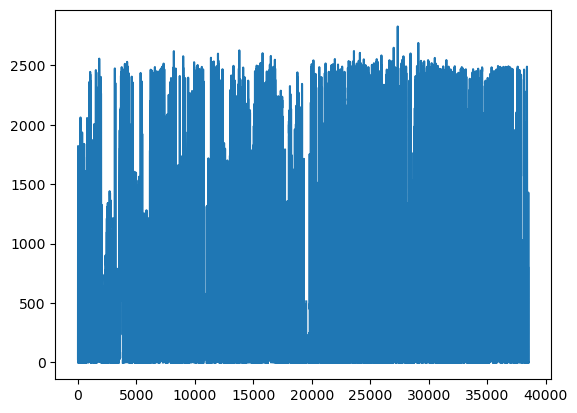

In [35]:
cross_border_extended["export_DE_LU_to_DK_1"].plot.line()

<Axes: >

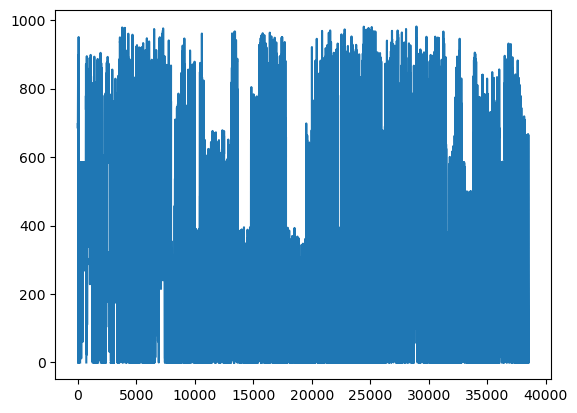

In [36]:
cross_border_extended["export_DE_50HzT_to_DK"].plot.line()

In [30]:
# Validate and save
validate_data(cross_border_extended, "Cross-border flows")
# cross_border_extended = make_hourly_intervals(cross_border_extended, START_DATE, END_DATE)
save_data(cross_border_extended, CROSS_BORDER_DIR / "entsoe_cross_border_flows_extended.csv", "Cross-border flows")


=== Validating Cross-border flows ===
Date range: 2021-10-01 00:00:00 to 2026-02-22 23:00:00
  export_DE_TenneT_to_CZ: 89.51% complete ✗
  import_DE_TenneT_to_CZ: 35.13% complete ✗
  export_DE_TenneT_to_AT: 99.49% complete ✓
  import_DE_TenneT_to_AT: 99.64% complete ✓
  export_DE_TenneT_to_NL: 42.20% complete ✗
  import_DE_TenneT_to_NL: 74.96% complete ✗
  export_DE_50HzT_to_PL: 28.31% complete ✗
  import_DE_50HzT_to_PL: 97.90% complete ✗
  export_DE_50HzT_to_CZ: 25.10% complete ✗
  import_DE_50HzT_to_CZ: 88.85% complete ✗
  export_DE_Amprion_to_AT: 41.80% complete ✗
  import_DE_Amprion_to_AT: 71.88% complete ✗
  export_DE_Amprion_to_CH: 51.33% complete ✗
  import_DE_Amprion_to_CH: 60.26% complete ✗
  export_DE_Amprion_to_FR: 72.60% complete ✗
  import_DE_Amprion_to_FR: 36.18% complete ✗
  export_DE_Amprion_to_BE: 64.35% complete ✗
  import_DE_Amprion_to_BE: 51.73% complete ✗
  export_DE_Amprion_to_NL: 72.13% complete ✗
  import_DE_Amprion_to_NL: 42.28% complete ✗
  export_DE_Transnet

In [16]:
cross_border = pd.read_csv(CROSS_BORDER_DIR / "entsoe_cross_border_flows_extended.csv", parse_dates=['begin_date', 'end_date'])

In [28]:
cross_border.isna().mean(numeric_only=True).sort_values(ascending=False).to_frame(name="percent_missing").assign(used=lambda df: df.index.str.contains("DE_LU")).to_csv("cross_border_missing.csv")

### Fetch Scheduled Commercial Exchanges

In [41]:
scheduled_exchanges_df = fetch_scheduled_commercial_exchanges(
    client,
    START_DATE,
    END_DATE,
    connections=REDISPATCHING_CROSS_BORDER_CONNECTIONS
)

Fetching scheduled commercial exchanges: 100%|██████████| 51/51 [02:10<00:00,  2.56s/it]


In [42]:
# Reverse connections to get the other direction of scheduled exchanges
REVERSED_CROSS_BORDER_CONNECTIONS = {f"{re.search(r'(.*)_to_(.*)', conn_title).group(2)}_to_{re.search(r'(.*)_to_(.*)', conn_title).group(1)}": (out_domain, in_domain) for conn_title, (in_domain, out_domain) in REDISPATCHING_CROSS_BORDER_CONNECTIONS.items()}

In [43]:
# Fetch the data
reversed_scheduled_exchanges_df = fetch_scheduled_commercial_exchanges(
    client,
    START_DATE,
    END_DATE,
    connections=REVERSED_CROSS_BORDER_CONNECTIONS
)

Fetching scheduled commercial exchanges: 100%|██████████| 51/51 [01:48<00:00,  2.13s/it]


In [44]:
full_scheduled_exchanges = pd.merge(scheduled_exchanges_df, reversed_scheduled_exchanges_df, on=['begin_date', 'end_date'], how='outer', validate='one_to_one')

In [45]:
full_scheduled_exchanges_extended = merge_with_existing_data(
    full_scheduled_exchanges,
    SCHEDULED_EXCHANGES_DIR / "entsoe_forecasted_scheduled_exchanges.csv",
    "Scheduled commercial exchanges",
    keep="last"
).drop(columns=["Unnamed: 0"])

Loaded existing Scheduled commercial exchanges from ../data/scheduled_exchanges/entsoe_forecasted_scheduled_exchanges.csv (37368 rows)
Merged Scheduled commercial exchanges: 38544 rows after merging and filling intervals


In [46]:
# Validate and save
validate_data(full_scheduled_exchanges_extended, "Scheduled commercial exchanges")
# full_scheduled_exchanges_extended = make_hourly_intervals(full_scheduled_exchanges_extended, START_DATE, END_DATE)
save_data(full_scheduled_exchanges_extended, SCHEDULED_EXCHANGES_DIR / "entsoe_forecasted_scheduled_exchanges_extended.csv", "Scheduled Commercial Exchanges")


=== Validating Scheduled commercial exchanges ===
Date range: 2021-10-01 00:00:00 to 2026-02-22 23:00:00
  schedule_da_DE_TenneT_to_CZ: 100.00% complete ✓
  schedule_da_DE_TenneT_to_AT: 100.00% complete ✓
  schedule_da_DE_TenneT_to_NL: 100.00% complete ✓
  schedule_da_DE_50HzT_to_PL: 100.00% complete ✓
  schedule_da_DE_50HzT_to_CZ: 100.00% complete ✓
  schedule_da_DE_Amprion_to_AT: 100.00% complete ✓
  schedule_da_DE_Amprion_to_CH: 100.00% complete ✓
  schedule_da_DE_Amprion_to_FR: 100.00% complete ✓
  schedule_da_DE_Amprion_to_BE: 100.00% complete ✓
  schedule_da_DE_Amprion_to_NL: 100.00% complete ✓
  schedule_da_DE_TransnetBW_to_AT: 100.00% complete ✓
  schedule_da_DE_TransnetBW_to_CH: 100.00% complete ✓
  schedule_da_DE_TransnetBW_to_FR: 100.00% complete ✓
  schedule_da_DE_LU_to_DK_1: 100.00% complete ✓
  schedule_da_DE_LU_to_DK_2: 100.00% complete ✓
  schedule_da_DE_LU_to_PL: 100.00% complete ✓
  schedule_da_DE_LU_to_CZ: 100.00% complete ✓
  schedule_da_DE_LU_to_AT: 100.00% comple

### Fetch Wind/PV Generation

In [47]:
# Fetch wind/PV generation data
wind_pv = fetch_wind_pv_generation(client, START_DATE, END_DATE)


=== Fetching Wind/PV Generation Data ===


Fetching wind/solar day_ahead forecast: 100%|██████████| 4/4 [00:25<00:00,  6.50s/it]


Day-ahead forecasts: 1272 rows


Fetching actual generation: 100%|██████████| 4/4 [00:08<00:00,  2.04s/it]

Actual generation: 1272 rows


In [48]:
wind_pv_extended = merge_with_existing_data(
    wind_pv,
    WIND_PV_DIR / "entsoe_wind_pv_generation_v2.csv",
    "Wind/PV generation",
    keep="last"
)

Loaded existing Wind/PV generation from ../data/wind_pv_generation/entsoe_wind_pv_generation_v2.csv (37368 rows)
Merged Wind/PV generation: 38544 rows after merging and filling intervals


In [49]:
# Validate and save
validate_data(wind_pv_extended, "Wind/PV generation")
# wind_pv_extended = make_hourly_intervals(wind_pv_extended, START_DATE, END_DATE)
save_data(wind_pv_extended, WIND_PV_DIR / "entsoe_wind_pv_generation_extended.csv", "Wind/PV generation")


=== Validating Wind/PV generation ===
Date range: 2021-10-01 00:00:00 to 2026-02-22 23:00:00
  forecast_day_ahead_DE_TenneT_Solar: 100.00% complete ✓
  forecast_day_ahead_DE_TenneT_Wind_Offshore: 100.00% complete ✓
  forecast_day_ahead_DE_TenneT_Wind_Onshore: 100.00% complete ✓
  forecast_day_ahead_DE_50HzT_Solar: 100.00% complete ✓
  forecast_day_ahead_DE_50HzT_Wind_Offshore: 100.00% complete ✓
  forecast_day_ahead_DE_50HzT_Wind_Onshore: 100.00% complete ✓
  forecast_day_ahead_DE_Amprion_Solar: 100.00% complete ✓
  forecast_day_ahead_DE_Amprion_Wind_Onshore: 100.00% complete ✓
  forecast_day_ahead_DE_TransnetBW_Solar: 100.00% complete ✓
  forecast_day_ahead_DE_TransnetBW_Wind_Onshore: 100.00% complete ✓
  generation_DE_TenneT_Solar: 100.00% complete ✓
  generation_DE_TenneT_Wind_Offshore: 100.00% complete ✓
  generation_DE_TenneT_Wind_Onshore: 100.00% complete ✓
  generation_DE_50HzT_Solar: 100.00% complete ✓
  generation_DE_50HzT_Wind_Offshore: 100.00% complete ✓
  generation_DE_50H

### Fetch congestion management costs

In [31]:
redispatching_congestion_costs = fetch_redispatching_congestion_management_costs(client, START_DATE, datetime(2026, 7, 1), regions=GERMAN_TSO_AREAS)

Fetching congestion management costs: 100%|██████████| 4/4 [01:37<00:00, 24.35s/it]


In [44]:
redispatching_congestion_costs["begin_date"] = pd.to_datetime(redispatching_congestion_costs["begin_date"]) + pd.Timedelta(hours=2)
redispatching_congestion_costs["end_date"] = pd.to_datetime(redispatching_congestion_costs["end_date"]) + pd.Timedelta(hours=2)

In [47]:
# Validate and save
save_data(redispatching_congestion_costs, REDISPATCHING_COSTS_DIR / "entsoe_redispatching_congestion_costs.csv", "Redispatching congestion costs")

Saved Redispatching congestion costs to ../data/redispatching_costs/entsoe_redispatching_congestion_costs.csv (58 rows)


### Comparison with TSO data

In [29]:
import pytz

def convert_to_utc_hourly(date_series: pd.Series, timezone: str) -> pd.Series:
    """
    Localize naive datetimes in `date_series` to `timezone` and convert to UTC.
    Ambiguous timestamps (clock rollback) are handled deterministically by choosing
    the 'later' (fold=1) occurrence. Non-existent timestamps (spring forward)
    are shifted forward by 1 hour.
    """
    tz = pytz.timezone(timezone)
    results = []

    for ts in date_series:
        if pd.isna(ts):
            results.append(pd.NaT)
            continue

        # ensure python datetime
        dt = pd.Timestamp(ts).to_pydatetime()

        try:
            aware = tz.localize(dt, is_dst=None)  # will raise on ambiguous / non-existent
        except pytz.AmbiguousTimeError:
            # choose the later occurrence (is_dst=True). Change to False to pick earlier.
            aware = tz.localize(dt, is_dst=True)
        except pytz.NonExistentTimeError:
            # shift forward into existence (spring gap) by 1 hour and localize
            dt2 = pd.Timestamp(dt) + pd.Timedelta(hours=1)
            aware = tz.localize(dt2.to_pydatetime(), is_dst=True)

        # convert to UTC tz-aware timestamp
        results.append(aware.astimezone(pytz.UTC))

    return pd.Series(results, index=date_series.index).dt.tz_localize(None)

In [63]:
wind_pv = pd.read_csv(WIND_PV_DIR / "entsoe_wind_pv_generation.csv", parse_dates=['begin_date', 'end_date'])
wind_pv["forecast_Wind_TenneT"] = wind_pv["forecast_day_ahead_DE_TenneT_Wind_Onshore"] + wind_pv["forecast_day_ahead_DE_TenneT_Wind_Offshore"]
wind_pv_tso_website = pd.read_csv(DATA_DIR / "wind_pv_generation" / "tennet_windpower.csv", sep=";", decimal=",")
wind_pv_tso_website["begin_date"] = pd.to_datetime(wind_pv_tso_website["Datum"] + " " + wind_pv_tso_website["Startzeit"], format="%Y-%m-%d %H:%M:%S")
wind_pv_tso_website["end_date"] = pd.to_datetime(wind_pv_tso_website["Datum"] + " " + wind_pv_tso_website["Endzeit"], format="%Y-%m-%d %H:%M:%S", errors='coerce')
wind_pv_tso_website_original = wind_pv_tso_website.copy()
wind_pv_tso_website = wind_pv_tso_website.rename(
    columns={
        "prognostiziert [MW]": "forecast",
        "tatsächlich [MW]": "actual",
        "Anteil Offshore [MW]": "offshore",
    }
).drop(columns=["Datum", "Startzeit", "Endzeit"])
wind_pv_tso_website["onshore"] = wind_pv_tso_website["actual"] - wind_pv_tso_website["offshore"]
wind_pv_tso_website = wind_pv_tso_website.groupby(wind_pv_tso_website["begin_date"].dt.floor("h"))[wind_pv_tso_website.select_dtypes("float64").columns].mean().reset_index()
# Align with UTC and the fact that in TenneT's data, the timestamp refers to the end of the hour
wind_pv_tso_website["begin_date"] = convert_to_utc_hourly(wind_pv_tso_website["begin_date"], "Europe/Berlin") #- pd.Timedelta(hours=1)
wind_pv_comparison = pd.merge(
    wind_pv[["begin_date", "forecast_Wind_TenneT", "forecast_day_ahead_DE_TenneT_Wind_Onshore", "forecast_day_ahead_DE_TenneT_Wind_Offshore", "generation_DE_TenneT_Wind_Onshore", "generation_DE_TenneT_Wind_Offshore"]],
    wind_pv_tso_website,
    on=["begin_date"],
    how="inner"
)

In [ ]:
wind_pv_comparison.loc[wind_pv_comparison["begin_date"].between("2023-07-05 22:00", "2023-07-07 23:00"), ["begin_date", "generation_DE_TenneT_Wind_Onshore", "generation_DE_TenneT_Wind_Offshore", "onshore", "offshore"]]

In [27]:
wind_pv_comparison[~np.isclose(wind_pv_comparison["forecast_Wind_TenneT"], wind_pv_comparison["forecast"])].shape[0] / wind_pv_comparison.shape[0]

0.1038460509059765

In [30]:
np.abs(wind_pv_comparison["forecast_Wind_TenneT"] - wind_pv_comparison["forecast"]).describe()

count    37358.000000
mean         3.311543
std         32.150237
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1002.750000
dtype: float64

In [31]:
np.abs(wind_pv_comparison["generation_DE_TenneT_Wind_Onshore"] - wind_pv_comparison["onshore"]).describe()

count    37363.000000
mean       125.785161
std        167.010868
min          0.000000
25%         27.418750
50%         71.170000
75%        161.228250
max       4767.635000
dtype: float64

In [77]:
wind_pv_tso_website[wind_pv_tso_website["begin_date"].between("2024-12-11 11:00", "2024-12-11 13:00")]

,begin_date,forecast,actual,offshore,onshore
28017,2024-12-11 11:00:00,1870.00,743.16350,236.53625,506.62725
28018,2024-12-11 12:00:00,2215.75,976.87425,325.90075,650.97350
28019,2024-12-11 13:00:00,2556.00,1219.71400,481.31250,738.40150


In [78]:
wind_pv_tso_website_original[wind_pv_tso_website_original["begin_date"].between("2024-12-11 12:00", "2024-12-11 13:00")]

,Datum,Startzeit,Endzeit,prognostiziert [MW],tatsächlich [MW],Anteil Offshore [MW],begin_date,end_date
112084,2024-12-11,12:00:00,12:15:00,1756.0,621.673,171.189,2024-12-11 12:00:00,2024-12-11 12:15:00
112085,2024-12-11,12:15:00,12:30:00,1837.0,719.464,217.853,2024-12-11 12:15:00,2024-12-11 12:30:00
112086,2024-12-11,12:30:00,12:45:00,1910.0,801.705,272.427,2024-12-11 12:30:00,2024-12-11 12:45:00
112087,2024-12-11,12:45:00,13:00:00,1977.0,829.812,284.676,2024-12-11 12:45:00,2024-12-11 13:00:00
112088,2024-12-11,13:00:00,13:15:00,2067.0,904.881,299.972,2024-12-11 13:00:00,2024-12-11 13:15:00


In [67]:
wind_pv_comparison.loc[wind_pv_comparison["generation_DE_TenneT_Wind_Onshore"] - wind_pv_comparison["onshore"] > 2_000, ["begin_date", "generation_DE_TenneT_Wind_Onshore", "onshore", "generation_DE_TenneT_Wind_Offshore", "offshore"]]

,begin_date,generation_DE_TenneT_Wind_Onshore,onshore,generation_DE_TenneT_Wind_Offshore,offshore
15035,2023-06-19 13:00:00,3960.6425,1831.6250,4641.9225,4642.850
15430,2023-07-06 00:00:00,7937.6975,3170.0625,2732.2825,2726.700
15431,2023-07-06 01:00:00,7292.8100,2781.5425,3005.2975,3006.000
15432,2023-07-06 02:00:00,6234.0625,3300.9025,3432.8050,3432.975


In [32]:
np.abs(wind_pv_comparison["generation_DE_TenneT_Wind_Offshore"] - wind_pv_comparison["offshore"]).describe()

count    37290.000000
mean         6.039473
std         14.085712
min          0.000000
25%          0.827500
50%          2.071000
75%          5.429375
max        406.116750
dtype: float64

In [68]:
wind_pv_comparison[wind_pv_comparison["generation_DE_TenneT_Wind_Offshore"] - wind_pv_comparison["offshore"] > 300]

,begin_date,forecast_Wind_TenneT,forecast_day_ahead_DE_TenneT_Wind_Onshore,forecast_day_ahead_DE_TenneT_Wind_Offshore,generation_DE_TenneT_Wind_Onshore,generation_DE_TenneT_Wind_Offshore,forecast,actual,offshore,onshore
26925,2024-10-27 00:00:00,6349.25,4628.00,1721.25,6844.8925,2484.7050,5982.625,7860.77800,2088.780875,5771.997125
28015,2024-12-11 11:00:00,1870.00,1023.50,846.50,497.4250,592.2150,1870.000,743.16350,236.536250,506.627250
28016,2024-12-11 12:00:00,2215.75,1170.00,1045.75,655.5925,732.0175,2215.750,976.87425,325.900750,650.973500
28017,2024-12-11 13:00:00,2556.00,1283.75,1272.25,715.9450,831.6925,2556.000,1219.71400,481.312500,738.401500


In [73]:
wind_pv_params = {
    "documentType": DOCUMENT_TYPES["actual_generation"],
    "processType": PROCESS_TYPES["realised"],
    "in_Domain": GERMAN_TSO_AREAS["DE_TenneT"],
    "periodStart": client._format_datetime(datetime(2024, 12, 11, 11, 0)),
    "periodEnd": client._format_datetime(datetime(2024, 12, 11, 12, 0)),
    "PsrType": "B18",  # Wind Onshore
}

wind_pv_xml_response = client._make_request(wind_pv_params)

In [74]:
wind_pv_xml_response.split("\n")

['<?xml version="1.0" encoding="utf-8"?>',
 '<GL_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:generationloaddocument:3:0">',
 '  <mRID>73b05148844b4754bac4487be80c56f5</mRID>',
 '  <revisionNumber>1</revisionNumber>',
 '  <type>A75</type>',
 '  <process.processType>A16</process.processType>',
 '  <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>',
 '  <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>',
 '  <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>',
 '  <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>',
 '  <createdDateTime>2026-01-20T10:29:28Z</createdDateTime>',
 '  <time_Period.timeInterval>',
 '    <start>2024-12-11T11:00Z</start>',
 '    <end>2024-12-11T12:00Z</end>',
 '  </time_Period.timeInterval>',
 '      <TimeSeries>',
 '        <mRID>1</mRID>',
 '        <businessType>A01</bus

## Summary

In [ ]:
print("\n" + "="*60)
print("DATA FETCHING COMPLETE")
print("="*60)

datasets = {
    "Day-ahead prices": day_ahead_prices,
    "Production/Consumption": production_consumption,
    "Cross-border flows": cross_border,
    "Wind/PV generation": wind_pv,
}

for name, df in datasets.items():
    if not df.empty:
        print(f"\n{name}:")
        print(f"  Rows: {len(df):,}")
        print(f"  Columns: {len(df.columns)}")
        print(f"  Date range: {df['begin_date'].min()} to {df['begin_date'].max()}")
        print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")

## Unavailability of Production and Generation Units (Outage Data)

This section fetches and processes outage data from ENTSO-E Transparency Platform (15.1.A&B).
We cannot use them for forecasting since:
- There is no single, publicly accessible, machine-consumable source that (a) covers Oct 2021–Dec 2025, (b) provides first-publication timestamps / version history, and (c) is consistent across TSOs in the way you need for leakage-safe day-ahead feature engineering.
- ENTSO-E’s historical export is effectively a repacked snapshot (createdDateTime tied to export/migration), so it cannot support an “as-of D-1 15:00” information set for 2021–2024. It only starts being correct after Oct 2025.
- Elia Group’s IIP feed helps conceptually, but in practice it only includes data from Oct 2025 and only transmission failures.

That's why the data will be used for possible diagnostics:
- Explain forecast errors (“misses coincide with large forced outages”)
- Label high-stress periods/regimes
- Run attribution analyses.

In [12]:
# Outage document types (15.1.A/B/C/D)
# Outage directories
OUTAGE_DIR = DATA_DIR / "outages"
OUTAGE_DIR.mkdir(parents=True, exist_ok=True)

# Configuration for forecast issue time
FORECAST_ISSUE_HOUR_LOCAL = 15  # 15:00 Europe/Berlin (day-ahead)
FORECAST_TIMEZONE = "Europe/Berlin"

OUTAGE_REASON_CODES = {
    "A95": "Complementary information",
    "B18": "Failure",
    "B19": "Forseen maintenance",
    "B20": "Shutdown",
    "B21": "Official exchange rate approved",
    "B22": "System regulation",
    "B23": "Frequency regulation",
    "B24": "Load flow overload",
    "B25": "Voltage level adjustment",
}

# Reason grouping for coarse categorization
REASON_GROUPS = {
    "Maintenance": ["Maintenance", "Planned maintenance", "Revision", "Inspection"],
    "Failure": ["Failure", "Forced outage", "Unplanned outage", "Technical failure", "Equipment failure"],
    "External": ["External constraints", "Grid constraints", "System operator request"],
    "Redispatch": ["Redispatch"],
    "Fuel": ["Fuel shortage", "Fuel supply", "Gas supply"],
    "Environmental": ["Environmental", "Weather", "Temperature"],
    "Testing": ["Testing", "Commissioning", "Trial operation"],
    "Other": ["Other", "Unknown", "Not specified"],
}

def map_reason_to_group(reason: str) -> str:
    """Map detailed reason to coarse group."""
    if pd.isna(reason) or reason == "":
        return "Other"
    reason_lower = str(reason).lower()
    for group, keywords in REASON_GROUPS.items():
        if any(kw.lower() in reason_lower for kw in keywords):
            return group
    return "Other"

### Outage Data Fetching Functions

In [13]:
def parse_outage_xml_to_dataframe(xml_text: str) -> pd.DataFrame:
    """
    Parse ENTSO-E unavailability XML response to DataFrame.
    
    Extracts:
    - InstanceCode (mRID): Unique outage event ID
    - VersionNumber (revisionNumber): Version of the record
    - VersionPublicationTimestamp (createdDateTime): When this version was published
    - Status (businessType): Active, Cancelled, Withdrawn, etc.
    - Type (docStatus): Planned vs Forced
    - Area/CTA: Control area (from registeredResource or biddingZone)
    - ProductionType (psrType): Fuel/technology
    - Reason: Maintenance reason
    - StartOutageUTC, EndOutageUTC: Overall outage window
    - Time series intervals with AvailableCapacityMW
    """
    if not xml_text:
        return pd.DataFrame()
    
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError as e:
        print(f"XML parsing error: {e}")
        return pd.DataFrame()
    
    # Detect namespace
    root_ns = root.tag.split('}')[0].strip('{') if '}' in root.tag else ''
    ns = {'ns': root_ns} if root_ns else {}
    
    def find_elem(parent, tag):
        """Find element with or without namespace."""
        if ns:
            elem = parent.find(f'.//{{{ns["ns"]}}}{tag}')
            if elem is None:
                elem = parent.find(f'.//{tag}')
        else:
            elem = parent.find(f'.//{tag}')
        return elem
    
    def find_all_elem(parent, tag):
        """Find all elements with or without namespace."""
        if ns:
            elems = parent.findall(f'.//{{{ns["ns"]}}}{tag}')
            if not elems:
                elems = parent.findall(f'.//{tag}')
        else:
            elems = parent.findall(f'.//{tag}')
        return elems
    
    def get_text(parent, tag, default=None):
        """Get text content of element."""
        elem = find_elem(parent, tag)
        return elem.text if elem is not None else default
    
    records = []
    
    # Get document-level info
    doc_created = get_text(root, 'createdDateTime')
    doc_revision = get_text(root, 'revisionNumber')
    outage_instance_code = get_text(root, 'mRID')
    if outage_instance_code is None:
        raise ValueError("Outage document missing mRID")
    
    # Get document-level reason (if present at root)
    doc_reason_elem = find_elem(root, 'Reason')
    reason_code = get_text(doc_reason_elem, 'code')
    if reason_code is not None:
        reason_text = OUTAGE_REASON_CODES.get(reason_code, reason_code)
    else:
        reason_text = None
    
    # Get document-level unavailability period (if present)
    doc_unavail_period = find_elem(root, 'unavailability_Time_Period.timeInterval')
    doc_start_outage = None
    doc_end_outage = None
    if doc_unavail_period is not None:
        doc_start_outage = get_text(doc_unavail_period, 'start')
        doc_end_outage = get_text(doc_unavail_period, 'end')
    
    # Find all TimeSeries (each represents one unavailability event)
    time_series_list = find_all_elem(root, 'TimeSeries')
    
    for ts in time_series_list:
        # Extract basic metadata
        ts_instance_code = outage_instance_code + "_" + get_text(ts, 'mRID')
        business_type = get_text(ts, 'businessType')  # A53=planned, A54=forced
        
        # Get revision/version (prefer TimeSeries level, fallback to document level)
        revision = get_text(ts, 'revisionNumber') or doc_revision or '1'
        
        # Get created/publication timestamp (prefer TimeSeries, fallback to document)
        version_pub_ts = get_text(ts, 'createdDateTime') or doc_created
        
        # Get bidding zone / control area
        in_domain = get_text(ts, 'biddingZone_Domain.mRID')
        
        # Map domain to TSO name
        tso_name = None
        for tso, eic in GERMAN_TSO_AREAS.items():
            if in_domain == eic:
                tso_name = tso
                break
        
        # Get production resource info - fields are direct children of TimeSeries
        resource_code = get_text(ts, 'production_RegisteredResource.mRID')
        resource_name = get_text(ts, 'production_RegisteredResource.name')
        resource_location = get_text(ts, 'production_RegisteredResource.location.name')
        
        # PSR type is a direct child with the full path
        psr_type = get_text(ts, 'production_RegisteredResource.pSRType.psrType')
        
        # Nominal capacity with full path
        nominal_capacity = None
        nominal_capacity_text = get_text(ts, 'production_RegisteredResource.pSRType.powerSystemResources.nominalP')
        if nominal_capacity_text:
            try:
                nominal_capacity = float(nominal_capacity_text)
            except (ValueError, TypeError):
                pass
        
        # Fallback: check for psrType at TimeSeries level (for older formats)
        if psr_type is None:
            psr_type = get_text(ts, 'psrType')
        
        psr_type_name = PSR_TYPES.get(psr_type, psr_type) if psr_type else None
        
        # Get status/docStatus
        doc_status = get_text(ts, 'docStatus')
        
        # Get outage period - try multiple tag patterns
        start_outage = None
        end_outage = None
        
        # Pattern 1: Unavailability_Time_Period
        unavail_period = find_elem(ts, 'Unavailability_Time_Period')
        if unavail_period is not None:
            time_interval = find_elem(unavail_period, 'timeInterval')
            if time_interval is not None:
                start_outage = get_text(time_interval, 'start')
                end_outage = get_text(time_interval, 'end')
        
        # Pattern 2: start_DateAndOrTime / end_DateAndOrTime
        if start_outage is None:
            start_date = get_text(ts, 'start_DateAndOrTime.date')
            start_time = get_text(ts, 'start_DateAndOrTime.time')
            if start_date and start_time:
                # Combine date and time
                start_outage = f"{start_date}T{start_time}"
        
        if end_outage is None:
            end_date = get_text(ts, 'end_DateAndOrTime.date')
            end_time = get_text(ts, 'end_DateAndOrTime.time')
            if end_date and end_time:
                end_outage = f"{end_date}T{end_time}"
        
        # Fallback to document-level period
        if start_outage is None:
            start_outage = doc_start_outage
        if end_outage is None:
            end_outage = doc_end_outage
        
        # Get available periods (time series with capacity values)
        available_periods = find_all_elem(ts, 'Available_Period')
        
        if not available_periods:
            # If no Available_Period, create single record with overall period
            record = {
                'InstanceCode': outage_instance_code,
                'TimeSeriesInstanceCode': ts_instance_code,
                'VersionNumber': int(revision) if revision else 1,
                'VersionPublicationTimestampUTC': pd.to_datetime(version_pub_ts),
                'Status': doc_status,
                'BusinessType': business_type,
                'Type': 'Planned' if business_type == 'A53' else ('Forced' if business_type == 'A54' else None),
                'TSO': tso_name,
                'ControlArea': in_domain,
                'ProductionType': psr_type,
                'ProductionTypeName': psr_type_name,
                'ResourceName': resource_name,
                'ResourceLocation': resource_location,
                'ResourceCode': resource_code,
                'NominalCapacityMW': nominal_capacity,
                'ReasonCode': reason_code,
                'ReasonText': reason_text,
                'ReasonGroup': map_reason_to_group(reason_text),
                'StartOutageUTC': pd.to_datetime(start_outage) if start_outage else None,
                'EndOutageUTC': pd.to_datetime(end_outage) if end_outage else None,
                'StartTimeSeriesUTC': pd.to_datetime(start_outage) if start_outage else None,
                'EndTimeSeriesUTC': pd.to_datetime(end_outage) if end_outage else None,
                'AvailableCapacityMW': None,
                'Resolution': None,
            }
            records.append(record)
        else:
            # Process each Available_Period
            for period in available_periods:
                time_interval = find_elem(period, 'timeInterval')
                if time_interval is None:
                    continue
                
                period_start = get_text(time_interval, 'start')
                period_end = get_text(time_interval, 'end')
                resolution = get_text(period, 'resolution')
                
                # Get Point elements (capacity values)
                points = find_all_elem(period, 'Point')
                
                if not points:
                    # Single capacity for entire period
                    quantity = get_text(period, 'quantity')
                    record = {
                        'InstanceCode': outage_instance_code,
                        'TimeSeriesInstanceCode': ts_instance_code,
                        'VersionNumber': int(revision) if revision else 1,
                        'VersionPublicationTimestampUTC': pd.to_datetime(version_pub_ts),
                        'Status': doc_status,
                        'BusinessType': business_type,
                        'Type': 'Planned' if business_type == 'A53' else ('Forced' if business_type == 'A54' else None),
                        'TSO': tso_name,
                        'ControlArea': in_domain,
                        'ProductionType': psr_type,
                        'ProductionTypeName': psr_type_name,
                        'ResourceName': resource_name,
                        'ResourceLocation': resource_location,
                        'ResourceCode': resource_code,
                        'NominalCapacityMW': nominal_capacity,
                        'ReasonCode': reason_code,
                        'ReasonText': reason_text,
                        'ReasonGroup': map_reason_to_group(reason_text),
                        'StartOutageUTC': pd.to_datetime(start_outage) if start_outage else None,
                        'EndOutageUTC': pd.to_datetime(end_outage) if end_outage else None,
                        'StartTimeSeriesUTC': pd.to_datetime(period_start) if period_start else None,
                        'EndTimeSeriesUTC': pd.to_datetime(period_end) if period_end else None,
                        'AvailableCapacityMW': float(quantity) if quantity else None,
                        'Resolution': resolution,
                    }
                    records.append(record)
                else:
                    # Multiple points with varying capacity
                    period_start_dt = pd.to_datetime(period_start)
                    period_end_dt = pd.to_datetime(period_end)
                    
                    # Determine interval duration from resolution
                    if resolution == 'PT1M':
                        interval_minutes = 1
                    elif resolution == 'PT15M':
                        interval_minutes = 15
                    elif resolution == 'PT30M':
                        interval_minutes = 30
                    elif resolution == 'PT60M' or resolution == 'PT1H':
                        interval_minutes = 60
                    elif resolution == 'P1D':
                        interval_minutes = 60 * 24
                    else:
                        interval_minutes = 60
                    
                    for pos_i, point in enumerate(points):
                        position = get_text(point, 'position')
                        quantity = get_text(point, 'quantity')
                        
                        if position is None:
                            continue
                        
                        pos = int(position)
                        point_start = period_start_dt + timedelta(minutes=interval_minutes * (pos - 1))
                        if pos_i < len(points) - 1:
                            next_position = get_text(points[pos_i + 1], 'position')
                            next_pos = int(next_position)
                            point_end = period_start_dt + timedelta(minutes=interval_minutes * (next_pos - 1))
                        else:
                            point_end = period_end_dt
                        
                        record = {
                            'InstanceCode': outage_instance_code,
                            'TimeSeriesInstanceCode': ts_instance_code,
                            'VersionNumber': int(revision) if revision else 1,
                            'VersionPublicationTimestampUTC': pd.to_datetime(version_pub_ts),
                            'Status': doc_status,
                            'BusinessType': business_type,
                            'Type': 'Planned' if business_type == 'A53' else ('Forced' if business_type == 'A54' else None),
                            'TSO': tso_name,
                            'ControlArea': in_domain,
                            'ProductionType': psr_type,
                            'ProductionTypeName': psr_type_name,
                            'ResourceName': resource_name,
                            'ResourceLocation': resource_location,
                            'ResourceCode': resource_code,
                            'NominalCapacityMW': nominal_capacity,
                            'ReasonCode': reason_code,
                            'ReasonText': reason_text,
                            'ReasonGroup': map_reason_to_group(reason_text),
                            'StartOutageUTC': pd.to_datetime(start_outage) if start_outage else None,
                            'EndOutageUTC': pd.to_datetime(end_outage) if end_outage else None,
                            'StartTimeSeriesUTC': point_start,
                            'EndTimeSeriesUTC': point_end,
                            'AvailableCapacityMW': float(quantity) if quantity else None,
                            'Resolution': resolution,
                        }
                        records.append(record)
    
    df = pd.DataFrame(records)
    
    if not df.empty:
        # Ensure UTC timezone-naive
        for col in ['VersionPublicationTimestampUTC', 'StartOutageUTC', 'EndOutageUTC', 
                    'StartTimeSeriesUTC', 'EndTimeSeriesUTC']:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col]).dt.tz_localize(None)
    
    return df

In [14]:
def fetch_unavailability_data(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
    document_types: List[str] = None,
    document_statuses: List[str] = None,
    business_types: List[str] = None,
) -> pd.DataFrame:
    """
    Fetch unavailability of production and generation units (15.1.A/B/C/D).
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date for outage window
    - end_date: End date for outage window
    - areas: Dict of area names to EIC codes (default: German TSOs)
    - doc_types: Document types to fetch (default: A77, A78 for planned/forced)
    
    Returns:
    DataFrame with all outage records including time series intervals
    """
    if areas is None:
        areas = GERMAN_TSO_AREAS

    if document_types is None:
        document_types = ['A77', 'A80']  # Production and generation units
    
    if document_statuses is None:
        document_statuses = ['A05']  # Only active outages

    if business_types is None:
        business_types = ['A53', 'A54']  # Planned and Forced outages
    
    all_data = []
    
    for area_name, eic_code in tqdm(areas.items(), desc="Fetching unavailability data"):
        area_data = []
        for doc_type in document_types:
            for business_type in business_types:
                for doc_status in document_statuses:
                
                    # Chunk by shorter periods (outage data can be large)
                    chunks = client._chunk_date_range(start_date, end_date, max_days=5)
                    
                    for chunk_start, chunk_end in chunks:
                        params = {
                            "documentType": doc_type,
                            "biddingZone_Domain": eic_code,
                            "periodStart": client._format_datetime(chunk_start),
                            "periodEnd": client._format_datetime(chunk_end),
                            "BusinessType": business_type,
                            "DocStatus": doc_status,
                        }
                        
                        xml_response = client._make_request(params)

                        if isinstance(xml_response, str):
                            xml_response_list = [xml_response]
                        else:
                            xml_response_list = xml_response
                        
                        if xml_response_list:
                            for xml_resp in xml_response_list:
                                df = parse_outage_xml_to_dataframe(xml_resp)
                                if not df.empty:
                                    df['DocumentType'] = doc_type
                                df['FetchArea'] = area_name
                                area_data.append(df)
                    
        if area_data:
            area_df = pd.concat(area_data, ignore_index=True)
            all_data.append(area_df)
    
    if not all_data:
        return pd.DataFrame()
    
    result = pd.concat(all_data, ignore_index=True)
    
    # Remove exact duplicates
    result = result.drop_duplicates()
    
    print(f"Fetched {len(result)} outage records")
    print(f"Unique outage events (InstanceCode): {result['InstanceCode'].nunique()}")
    
    return result

In [ ]:
outages_raw = fetch_unavailability_data(
    client,
    start_date=datetime(2021, 10, 1),
    end_date=datetime(2021, 11, 1),
)

In [29]:
outages_raw["ReasonText"].value_counts()

ReasonText
Forseen maintenance          1076
Failure                       913
Complementary information      24
Shutdown                       17
Name: count, dtype: int64

In [32]:
planned_individual_outages = outages_raw.query("ReasonText == 'Forseen maintenance' and VersionNumber == 1").sort_values(["InstanceCode", "StartOutageUTC"]).groupby("InstanceCode")[["StartOutageUTC", "StartTimeSeriesUTC", "VersionPublicationTimestampUTC"]].first()

In [33]:
pd.concat([
    (planned_individual_outages["StartTimeSeriesUTC"] - planned_individual_outages["VersionPublicationTimestampUTC"]).describe(),
    (planned_individual_outages["StartTimeSeriesUTC"] - planned_individual_outages["VersionPublicationTimestampUTC"]).quantile([0.01, 0.05, 0.1, 0.8, 0.9, 0.99])
], axis=0)

count                               210
mean     -1456 days +15:52:40.538095248
std          24 days 20:58:58.508778178
min                -1638 days +05:23:08
25%         -1461 days +06:45:48.500000
50%                -1455 days +21:53:36
75%         -1443 days +22:03:33.500000
max                -1436 days +17:05:18
0.01        -1601 days +06:23:26.520000
0.05        -1466 days +07:06:26.450000
0.1         -1465 days +11:56:35.500000
0.8         -1441 days +23:50:50.600000
0.9                -1438 days +11:39:15
0.99        -1436 days +15:19:31.790000
dtype: object

In [144]:
pd.concat([
    (planned_individual_outages["StartTimeSeriesUTC"] - planned_individual_outages["VersionPublicationTimestampUTC"]).describe(),
    (planned_individual_outages["StartTimeSeriesUTC"] - planned_individual_outages["VersionPublicationTimestampUTC"]).quantile([0.8, 0.9, 0.99])
], axis=0)

count                            1491
mean     -11 days +17:02:32.127431255
std        24 days 13:12:18.212311420
min               -324 days +15:32:36
25%                -17 days +11:23:06
50%                 -1 days +02:35:38
75%                 -1 days +16:38:51
max                  72 days 12:50:15
0.8                 -1 days +18:53:15
0.9                 -1 days +23:07:56
0.99        4 days 08:48:13.999999999
dtype: object

In [35]:
redispatch_xml = client._make_request({
    "documentType": "A63",
    "businessType": "A85",
    "out_Domain": GERMAN_TSO_AREAS["DE_TenneT"],
    "in_Domain": GERMAN_TSO_AREAS["DE_TenneT"],
    "periodStart": client._format_datetime(datetime(2021, 10, 1)),
    "periodEnd": client._format_datetime(datetime(2021, 10, 31)),
})

Bad Request (400): Invalid parameters - {'documentType': 'A63', 'businessType': 'A85', 'out_Domain': '10YDE-EON------1', 'in_Domain': '10YDE-EON------1', 'periodStart': '202110010000', 'periodEnd': '202110310000', 'securityToken': '9e842c53-0571-48b7-a3b6-7637dfe0868b'}


## Redispatching Internal Data Fetching

Fetch Redispatching Internal data (13.1.A) from ENTSO-E Transparency Platform.
This includes internal redispatch measures for Germany (per control area).

In [60]:
# Mapping codes for redispatch data
FLOW_DIRECTION_MAPPING = {
    "A01": "up",
    "A02": "down",
}

PSR_TYPE_MAPPING = {
    "A04": "generation",
    "A05": "load",
}

REDISPATCH_REASON_CODES = {
    "B24": "Load flow overflow",
    "B25": "Voltage level adjustment",
    "A95": "Complementary information",
}


def parse_redispatch_xml_to_dataframe(xml_text: str) -> pd.DataFrame:
    """
    Parse ENTSO-E Redispatching Internal XML response to DataFrame.
    
    Handles sparse time series data by forward-filling values until the next 
    Point entry or the end of the period.
    
    Returns DataFrame with columns:
    - timestamp_utc: Start time of each interval (UTC)
    - doc_mrid: Document-level mRID
    - doc_revision_number: Document-level revision number
    - ts_mrid: TimeSeries mRID for tracking (doc_mrid + '_' + ts.mRID)
    - tso: TSO name (from GERMAN_TSO_AREAS mapping)
    - in_domain: Control area EIC code
    - out_domain: Control area EIC code
    - psr_type: A04 (generation) or A05 (load)
    - psr_type_name: "generation" or "load"
    - flow_direction: A01 (up) or A02 (down)
    - flow_direction_name: "up" or "down"
    - quantity_mwh: Redispatch volume in MWh
    - quantity_unit: Unit of measure
    - resolution: Time resolution (e.g., PT15M)
    - curve_type: Curve type (A03 = variable sized block)
    - reason_labels: Comma-separated list of reason labels
    - business_type: Business type (A85)
    """
    if not xml_text:
        return pd.DataFrame()
    
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError as e:
        print(f"XML parsing error: {e}")
        return pd.DataFrame()
    
    # Detect namespace
    root_ns = root.tag.split('}')[0].strip('{') if '}' in root.tag else ''
    ns = {'ns': root_ns} if root_ns else {}
    
    def find_elem(parent, tag):
        """Find element with or without namespace."""
        if ns:
            elem = parent.find(f'.//{{{ns["ns"]}}}{tag}')
            if elem is None:
                elem = parent.find(f'.//{tag}')
        else:
            elem = parent.find(f'.//{tag}')
        return elem
    
    def find_all_elem(parent, tag):
        """Find all elements with or without namespace."""
        if ns:
            elems = parent.findall(f'.//{{{ns["ns"]}}}{tag}')
            if not elems:
                elems = parent.findall(f'.//{tag}')
        else:
            elems = parent.findall(f'.//{tag}')
        return elems
    
    def get_text(parent, tag, default=None):
        """Get text content of element."""
        elem = find_elem(parent, tag)
        return elem.text if elem is not None else default
    
    records = []
    
    # Get document-level metadata
    doc_mrid = get_text(root, 'mRID')
    doc_revision_number = get_text(root, 'revisionNumber', '1')
    
    # Find all TimeSeries elements
    time_series_list = find_all_elem(root, 'TimeSeries')
    
    for ts in time_series_list:
        # Extract metadata
        ts_mrid_raw = get_text(ts, 'mRID')
        ts_mrid = f"{doc_mrid}_{ts_mrid_raw}" if doc_mrid and ts_mrid_raw else ts_mrid_raw
        business_type = get_text(ts, 'businessType')  # Should be A85
        
        # Get domain info
        in_domain = get_text(ts, 'in_Domain.mRID')
        out_domain = get_text(ts, 'out_Domain.mRID')
        
        # Map domain to TSO name
        tso_name = None
        for tso, eic in GERMAN_TSO_AREAS.items():
            if in_domain == eic:
                tso_name = tso
                break
        
        # Get PSR type (A04=generation, A05=load)
        psr_type = get_text(ts, 'mktPSRType.psrType')
        psr_type_name = PSR_TYPE_MAPPING.get(psr_type, psr_type)
        
        # Get flow direction (A01=up, A02=down)
        flow_direction = get_text(ts, 'flowDirection.direction')
        flow_direction_name = FLOW_DIRECTION_MAPPING.get(flow_direction, flow_direction)
        
        # Get unit of measure
        quantity_unit = get_text(ts, 'quantity_Measure_Unit.name')
        
        # Get curve type
        curve_type = get_text(ts, 'curveType')  # A03 = variable sized block
        
        # Get reason codes and map to labels
        reason_elems = find_all_elem(ts, 'Reason')
        reason_labels = []
        for reason_elem in reason_elems:
            code = get_text(reason_elem, 'code')
            if code:
                label = REDISPATCH_REASON_CODES.get(code, code)
                reason_labels.append(label)
        reason_labels_str = ','.join(reason_labels) if reason_labels else None
        
        # Process each Period
        periods = find_all_elem(ts, 'Period')
        
        for period in periods:
            time_interval = find_elem(period, 'timeInterval')
            if time_interval is None:
                continue
            
            period_start = get_text(time_interval, 'start')
            period_end = get_text(time_interval, 'end')
            resolution = get_text(period, 'resolution')
            
            if not period_start or not period_end:
                continue
            
            period_start_dt = pd.to_datetime(period_start)
            period_end_dt = pd.to_datetime(period_end)
            
            # Determine interval duration from resolution
            if resolution == 'PT1M':
                interval_minutes = 1
            elif resolution == 'PT15M':
                interval_minutes = 15
            elif resolution == 'PT30M':
                interval_minutes = 30
            elif resolution == 'PT60M' or resolution == 'PT1H':
                interval_minutes = 60
            elif resolution == 'P1D':
                interval_minutes = 60 * 24
            else:
                interval_minutes = 15  # Default to 15 min for redispatch
            
            # Calculate total number of intervals in the period
            total_intervals = int((period_end_dt - period_start_dt).total_seconds() / (interval_minutes * 60))
            
            # Get all Point elements
            points = find_all_elem(period, 'Point')
            
            if not points:
                continue
            
            # Build a dict of position -> quantity for sparse points
            point_data = {}
            for point in points:
                position = get_text(point, 'position')
                quantity = get_text(point, 'quantity')
                if position is not None:
                    point_data[int(position)] = float(quantity) if quantity else 0.0
            
            # Forward-fill values: for each interval, use the value from the most recent Point
            current_quantity = 0.0  # Default if no point at position 1
            
            for interval_idx in range(1, total_intervals + 1):
                # Check if there's a new value at this position
                if interval_idx in point_data:
                    current_quantity = point_data[interval_idx]
                
                # Calculate timestamp for this interval
                timestamp = period_start_dt + timedelta(minutes=interval_minutes * (interval_idx - 1))
                end_timestamp = timestamp + timedelta(minutes=interval_minutes)
                
                record = {
                    'begin_timestamp_utc': timestamp,
                    'end_timestamp_utc': end_timestamp,
                    'doc_mrid': doc_mrid,
                    'doc_revision_number': int(doc_revision_number) if doc_revision_number else 1,
                    'ts_mrid': ts_mrid,
                    'tso': tso_name,
                    'in_domain': in_domain,
                    'out_domain': out_domain,
                    'psr_type': psr_type,
                    'psr_type_name': psr_type_name,
                    'flow_direction': flow_direction,
                    'flow_direction_name': flow_direction_name,
                    'quantity_mwh': current_quantity,
                    'quantity_unit': quantity_unit,
                    'resolution': resolution,
                    'curve_type': curve_type,
                    'reason_labels': reason_labels_str,
                    'business_type': business_type,
                }
                records.append(record)
    
    df = pd.DataFrame(records)
    
    if not df.empty:
        # Ensure UTC timezone-naive
        df['begin_timestamp_utc'] = pd.to_datetime(df['begin_timestamp_utc']).dt.tz_localize(None)
        df['end_timestamp_utc'] = pd.to_datetime(df['end_timestamp_utc']).dt.tz_localize(None)
        df = df.sort_values(['begin_timestamp_utc', 'end_timestamp_utc', 'tso', 'psr_type_name', 'flow_direction_name']).reset_index(drop=True)
    
    return df

In [61]:
class MaxInstancesExceededError(Exception):
    """Raised when ENTSO-E API returns error 999 (max instances exceeded)."""
    def __init__(self, message: str, num_instances: int = None, max_allowed: int = None):
        super().__init__(message)
        self.num_instances = num_instances
        self.max_allowed = max_allowed


def _check_max_instances_error(response_text: str) -> bool:
    """
    Check if the response contains a max instances exceeded error (code 999).
    Returns True if error detected, False otherwise.
    """
    if not response_text:
        return False
    
    if "<Reason>" in response_text and "<code>999</code>" in response_text:
        if "exceeds the allowed maximum" in response_text:
            return True
    return False


def _parse_max_instances_error(response_text: str) -> tuple[int, int]:
    """
    Parse the number of instances and max allowed from error message.
    Returns (num_instances, max_allowed) or (None, None) if parsing fails.
    """
    import re
    match = re.search(r'The number of instances \((\d+)\) exceeds the allowed maximum \((\d+)\)', response_text)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None


def fetch_redispatch_chunk_with_adaptive_window(
    client: ENTSOEClient,
    area_name: str,
    eic_code: str,
    chunk_start: datetime,
    chunk_end: datetime,
    initial_hours: int,
    min_hours: int = 1,
    min_delay: float = 3.0,
    max_delay: float = 5.0,
) -> tuple[List[pd.DataFrame], int]:
    """
    Fetch redispatch data for a time range with adaptive window sizing.
    
    If the API returns a 'max instances exceeded' error, progressively
    halve the window size until success or min_hours is reached.
    
    Parameters:
    - client: ENTSOEClient instance
    - area_name: Name of the area (for logging)
    - eic_code: EIC code for the area
    - chunk_start: Start datetime
    - chunk_end: End datetime
    - initial_hours: Initial window size in hours
    - min_hours: Minimum window size in hours (default: 1)
    - min_delay: Minimum delay between requests
    - max_delay: Maximum delay between requests
    
    Returns:
    - Tuple of (list of DataFrames, successful_window_hours)
    """
    all_data = []
    current_hours = initial_hours
    current_start = chunk_start
    
    while current_start < chunk_end:
        # Calculate the window end
        window_end = min(current_start + timedelta(hours=current_hours), chunk_end)
        
        params = {
            "documentType": "A63",  # Redispatching document
            "businessType": "A85",  # Internal redispatch
            "in_Domain": eic_code,
            "out_Domain": eic_code,
            "periodStart": client._format_datetime(current_start),
            "periodEnd": client._format_datetime(window_end),
        }
        
        # Make request with explicit handling of max instances error
        params_with_token = {**params, "securityToken": client.api_key}
        
        try:
            response = client.session.get(client.base_url, params=params_with_token, timeout=60)
            
            if response.status_code == 200:
                # Check for max instances error in successful response
                if _check_max_instances_error(response.text):
                    num_inst, max_allowed = _parse_max_instances_error(response.text)
                    print(f"\n⚠️  Max instances exceeded for {area_name} ({current_start.date()} - {window_end.date()}): "
                          f"{num_inst} instances > {max_allowed} allowed")
                    
                    # Halve the window size
                    new_hours = current_hours // 2
                    if new_hours < min_hours:
                        print(f"❌ Cannot reduce window below {min_hours} hour(s). Skipping this period.")
                        current_start = window_end
                        time.sleep(random.uniform(min_delay, max_delay))
                        continue
                    
                    print(f"↘️  Reducing window from {current_hours}h to {new_hours}h")
                    current_hours = new_hours
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue  # Retry with smaller window, don't advance current_start
                
                # Check for "no data" response
                if "<Reason>" in response.text and "No matching data found" in response.text:
                    # No data for this period, move on
                    current_start = window_end
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue
                
                # Success - parse the data
                xml_response = client._decode_and_parse(response.content)
                
                if xml_response:
                    if isinstance(xml_response, list):
                        for xml_text in xml_response:
                            df = parse_redispatch_xml_to_dataframe(xml_text)
                            if not df.empty:
                                all_data.append(df)
                    else:
                        df = parse_redispatch_xml_to_dataframe(xml_response)
                        if not df.empty:
                            all_data.append(df)
                
                # Success - move to next window
                current_start = window_end
                time.sleep(random.uniform(min_delay, max_delay))
                
            elif response.status_code == 400:
                # Check if it's a max instances error
                if _check_max_instances_error(response.text):
                    num_inst, max_allowed = _parse_max_instances_error(response.text)
                    print(f"\n⚠️  Max instances exceeded (400) for {area_name} ({current_start.date()} - {window_end.date()}): "
                          f"{num_inst} instances > {max_allowed} allowed")
                    
                    # Halve the window size
                    new_hours = current_hours // 2
                    if new_hours < min_hours:
                        print(f"❌ Cannot reduce window below {min_hours} hour(s). Skipping this period.")
                        current_start = window_end
                        time.sleep(random.uniform(min_delay, max_delay))
                        continue
                    
                    print(f"↘️  Reducing window from {current_hours}h to {new_hours}h")
                    current_hours = new_hours
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue
                else:
                    print(f"Bad Request (400): {response.text[:200]}...")
                    current_start = window_end
                    time.sleep(random.uniform(min_delay, max_delay))
                    
            elif response.status_code == 409 or response.status_code == 429:
                print(f"Rate limit hit ({response.status_code}), waiting 60s...")
                time.sleep(60)
                continue  # Retry same request
                
            else:
                print(f"HTTP Error {response.status_code}: {response.text[:200]}...")
                current_start = window_end
                time.sleep(random.uniform(min_delay, max_delay))
                
        except requests.exceptions.Timeout:
            print("Request timed out, retrying in 5s...")
            time.sleep(5)
            continue
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            current_start = window_end
            time.sleep(random.uniform(min_delay, max_delay))
    
    return all_data, current_hours


def fetch_redispatch_internal_data(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    areas: Dict[str, str] = None,
    chunk_days: int = 10,
    min_delay: float = 3.0,
    max_delay: float = 5.0,
    adaptive_chunking: bool = True,
    min_chunk_hours: int = 1,
) -> pd.DataFrame:
    """
    Fetch Redispatching Internal data (13.1.A) from ENTSO-E.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date for data fetching
    - end_date: End date for data fetching
    - areas: Dict of area names to EIC codes (default: German TSOs)
    - chunk_days: Number of days per request chunk (default: 10)
    - min_delay: Minimum delay between requests in seconds (default: 3.0)
    - max_delay: Maximum delay between requests in seconds (default: 5.0)
    - adaptive_chunking: If True, automatically reduce chunk size on max instances error (default: True)
    - min_chunk_hours: Minimum chunk size in hours when using adaptive chunking (default: 1)
    
    Returns:
    DataFrame with all redispatch records
    """
    if areas is None:
        areas = GERMAN_TSO_AREAS
    
    all_data = []
    
    # Create date chunks
    date_chunks = client._chunk_date_range(start_date, end_date, max_days=chunk_days)
    initial_hours = chunk_days * 24
    
    total_requests = len(areas) * len(date_chunks)
    
    with tqdm(total=total_requests, desc="Fetching redispatch internal data") as pbar:
        for area_name, eic_code in areas.items():
            # Track successful window size per area (can be reused across chunks)
            current_window_hours = initial_hours
            
            for chunk_start, chunk_end in date_chunks:
                if adaptive_chunking:
                    # Use adaptive chunking with progressive window reduction
                    chunk_data, successful_hours = fetch_redispatch_chunk_with_adaptive_window(
                        client=client,
                        area_name=area_name,
                        eic_code=eic_code,
                        chunk_start=chunk_start,
                        chunk_end=chunk_end,
                        initial_hours=current_window_hours,
                        min_hours=min_chunk_hours,
                        min_delay=min_delay,
                        max_delay=max_delay,
                    )
                    all_data.extend(chunk_data)
                    
                    # Remember successful window size for next chunk
                    if successful_hours < current_window_hours:
                        current_window_hours = successful_hours
                        print(f"📝 Adjusted window size to {current_window_hours}h for {area_name}")
                else:
                    # Original behavior without adaptive chunking
                    params = {
                        "documentType": "A63",
                        "businessType": "A85",
                        "in_Domain": eic_code,
                        "out_Domain": eic_code,
                        "periodStart": client._format_datetime(chunk_start),
                        "periodEnd": client._format_datetime(chunk_end),
                    }
                    
                    xml_response = client._make_request(params)
                    
                    if xml_response:
                        if isinstance(xml_response, list):
                            for xml_text in xml_response:
                                df = parse_redispatch_xml_to_dataframe(xml_text)
                                if not df.empty:
                                    all_data.append(df)
                        else:
                            df = parse_redispatch_xml_to_dataframe(xml_response)
                            if not df.empty:
                                all_data.append(df)
                    
                    time.sleep(random.uniform(min_delay, max_delay))
                
                pbar.update(1)
                pbar.set_postfix(area=area_name, chunk=f"{chunk_start.date()} to {chunk_end.date()}")
    
    if all_data:
        result_df = pd.concat(all_data, ignore_index=True)
        
        result_df = result_df.sort_values(
            ['begin_timestamp_utc', 'tso']
        ).reset_index(drop=True)
        
        return result_df
    
    return pd.DataFrame()

### Fetch Redispatching Internal Data for German TSOs

In [ ]:
# Fetch redispatch internal data for German TSOs
# Note: Uses adaptive chunking - if API returns "max instances exceeded" error,
# the window will automatically be halved until data can be fetched (min 1 hour)
redispatch_internal_df = fetch_redispatch_internal_data(
    client=client,
    start_date=datetime(2021, 10, 1),
    end_date=datetime(2026, 1, 5),
    areas={tso: data for tso, data in GERMAN_TSO_AREAS.items() if tso in ["DE_TenneT"]},
    chunk_days=2,  # Initial chunk size (will be reduced automatically if needed)
    min_delay=3.0,
    max_delay=5.0,
    adaptive_chunking=True,  # Enable automatic window reduction on error
    min_chunk_hours=1,  # Minimum window size before giving up
)

print(f"Fetched {len(redispatch_internal_df)} redispatch internal records")
print(f"Date range: {redispatch_internal_df['begin_timestamp_utc'].min()} to {redispatch_internal_df['begin_timestamp_utc'].max()}")
print(f"\nTSOs: {redispatch_internal_df['tso'].unique()}")
print(f"PSR types: {redispatch_internal_df['psr_type_name'].unique()}")
print(f"Flow directions: {redispatch_internal_df['flow_direction_name'].unique()}")

In [16]:
agg_redispatch_tennet = redispatch_internal_df.query("tso == 'DE_TenneT'").groupby(["ts_mrid", "flow_direction_name"]).agg(
    total_load=pd.NamedAgg(column="quantity_mwh", aggfunc=lambda x: np.sum(x)),
    mean_load=pd.NamedAgg(column="quantity_mwh", aggfunc=lambda x: np.mean(x[x > 0]) * 4),
    max_load=pd.NamedAgg(column="quantity_mwh", aggfunc=lambda x: np.max(x) * 4),
    start_date=pd.NamedAgg(column="begin_timestamp_utc", aggfunc="min"),
    end_date=pd.NamedAgg(column="end_timestamp_utc", aggfunc="max"),
)


In [18]:
agg_redispatch_tennet[agg_redispatch_tennet["mean_load"].notna()].to_csv("agg_entsoe_nov_2022_test_data.csv")

In [26]:
agg_redispatch_tennet[agg_redispatch_tennet["mean_load"].notna()].reset_index().sort_values(["flow_direction_name","start_date", "end_date"]) #["start_date"] >= datetime(2021, 10, 1)]

,ts_mrid,flow_direction_name,total_load,mean_load,max_load,start_date,end_date
1,dc4b8ee6563a472387ecb5520df7a56f_2,down,14863.25,619.302083,960.0,2022-10-31 23:00:00,2022-11-01 23:00:00
2,dc4b8ee6563a472387ecb5520df7a56f_3,down,1487.50,85.000000,130.0,2022-11-01 05:30:00,2022-11-01 23:00:00
3,dc4b8ee6563a472387ecb5520df7a56f_4,down,195.00,39.000000,40.0,2022-11-01 09:00:00,2022-11-01 23:00:00
4,dc4b8ee6563a472387ecb5520df7a56f_5,down,107.50,25.294118,30.0,2022-11-01 11:00:00,2022-11-01 23:00:00
6,dc4b8ee6563a472387ecb5520df7a56f_7,down,2402.50,100.104167,130.0,2022-11-01 23:00:00,2022-11-02 23:00:00
7,dc4b8ee6563a472387ecb5520df7a56f_8,down,105.00,21.000000,30.0,2022-11-01 23:30:00,2022-11-02 23:00:00
0,dc4b8ee6563a472387ecb5520df7a56f_1,up,2880.00,120.000000,120.0,2022-10-31 23:00:00,2022-11-01 23:00:00
5,dc4b8ee6563a472387ecb5520df7a56f_6,up,735.00,117.600000,120.0,2022-11-01 23:00:00,2022-11-02 23:00:00


In [ ]:
# Preview the data
redispatch_internal_df.head(20)

In [ ]:
# Summary statistics by TSO and direction
summary = redispatch_internal_df.groupby(['tso', 'psr_type_name', 'flow_direction_name']).agg({
    'quantity_mwh': ['sum', 'mean', 'count'],
    'timestamp_utc': ['min', 'max']
}).round(2)
summary

In [ ]:
# Save to CSV
REDISPATCH_DIR = DATA_DIR / "redispatch_internal"
REDISPATCH_DIR.mkdir(parents=True, exist_ok=True)

output_file = REDISPATCH_DIR / "entsoe_redispatch_internal_germany.csv"
redispatch_internal_df.to_csv(output_file, index=False)
print(f"Saved redispatch internal data to {output_file}")

In [ ]:
# Optionally: Pivot to get a wider format with columns for each TSO/direction combination
redispatch_pivot = redispatch_internal_df.pivot_table(
    index='timestamp_utc',
    columns=['tso', 'psr_type_name', 'flow_direction_name'],
    values='quantity_mwh',
    aggfunc='sum'
).fillna(0)

# Flatten column names
redispatch_pivot.columns = ['_'.join(col).strip() for col in redispatch_pivot.columns.values]
redispatch_pivot = redispatch_pivot.reset_index()

print(f"Pivot shape: {redispatch_pivot.shape}")
redispatch_pivot.head()

In [ ]:
# Save pivoted data
pivot_output_file = REDISPATCH_DIR / "entsoe_redispatch_internal_germany_pivot.csv"
redispatch_pivot.to_csv(pivot_output_file, index=False)
print(f"Saved pivoted redispatch data to {pivot_output_file}")

## Cross-Border Redispatching Data Fetching (13.1.A)

Fetch Cross-Border Redispatching data from ENTSO-E Transparency Platform.
This includes redispatch measures between different control areas/bidding zones.

In [6]:
# Market participant role codes mapping
MARKET_PARTICIPANT_ROLES = {
    "A32": "Market Operator",
    "A33": "Metered Data Responsible",
    "A39": "Data Provider",
    "A44": "Balance Responsible Party",
    "A45": "Metering Point Administrator",
    "A46": "System Operator",
    "A49": "Balance Service Provider",
}

# Additional EIC codes for market participants (ENTSO-E)
MARKET_PARTICIPANTS = {
    "10X1001A1001A450": "ENTSO-E",
}

# Combine all known EIC codes for reverse lookup
ALL_EIC_CODES = {
    **{v: k for k, v in BIDDING_ZONES.items()},
    **{v: k for k, v in GERMAN_TSO_AREAS.items()},
    **MARKET_PARTICIPANTS,
}


def parse_cross_border_redispatch_xml_to_dataframe(xml_text: str) -> pd.DataFrame:
    """
    Parse ENTSO-E Cross-Border Redispatching XML response to DataFrame.
    
    Similar to internal redispatch but includes additional fields:
    - sender_mrid / sender_mrid_name: Sender market participant
    - sender_role / sender_role_name: Sender market role
    - receiver_mrid / receiver_mrid_name: Receiver market participant  
    - receiver_role / receiver_role_name: Receiver market role
    
    Returns DataFrame with columns for cross-border redispatch data.
    """
    if not xml_text:
        return pd.DataFrame()
    
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError as e:
        print(f"XML parsing error: {e}")
        return pd.DataFrame()
    
    # Detect namespace
    root_ns = root.tag.split('}')[0].strip('{') if '}' in root.tag else ''
    ns = {'ns': root_ns} if root_ns else {}
    
    def find_elem(parent, tag):
        """Find element with or without namespace."""
        if ns:
            elem = parent.find(f'.//{{{ns["ns"]}}}{tag}')
            if elem is None:
                elem = parent.find(f'.//{tag}')
        else:
            elem = parent.find(f'.//{tag}')
        return elem
    
    def find_all_elem(parent, tag):
        """Find all elements with or without namespace."""
        if ns:
            elems = parent.findall(f'.//{{{ns["ns"]}}}{tag}')
            if not elems:
                elems = parent.findall(f'.//{tag}')
        else:
            elems = parent.findall(f'.//{tag}')
        return elems
    
    def get_text(parent, tag, default=None):
        """Get text content of element."""
        elem = find_elem(parent, tag)
        return elem.text if elem is not None else default
    
    records = []
    
    # Get document-level metadata
    doc_mrid = get_text(root, 'mRID')
    doc_revision_number = get_text(root, 'revisionNumber', '1')
    
    # Get market participant information (document-level)
    sender_mrid = get_text(root, 'sender_MarketParticipant.mRID')
    sender_role = get_text(root, 'sender_MarketParticipant.marketRole.type')
    receiver_mrid = get_text(root, 'receiver_MarketParticipant.mRID')
    receiver_role = get_text(root, 'receiver_MarketParticipant.marketRole.type')
    
    # Map market participant mRIDs to names
    sender_mrid_name = ALL_EIC_CODES.get(sender_mrid, sender_mrid)
    receiver_mrid_name = ALL_EIC_CODES.get(receiver_mrid, receiver_mrid)
    
    # Map market participant roles to names
    sender_role_name = MARKET_PARTICIPANT_ROLES.get(sender_role, sender_role)
    receiver_role_name = MARKET_PARTICIPANT_ROLES.get(receiver_role, receiver_role)
    
    # Find all TimeSeries elements
    time_series_list = find_all_elem(root, 'TimeSeries')
    
    for ts in time_series_list:
        # Extract metadata
        ts_mrid_raw = get_text(ts, 'mRID')
        ts_mrid = f"{doc_mrid}_{ts_mrid_raw}" if doc_mrid and ts_mrid_raw else ts_mrid_raw
        business_type = get_text(ts, 'businessType')  # Should be A46 for cross-border
        
        # Get domain info
        in_domain = get_text(ts, 'in_Domain.mRID')
        out_domain = get_text(ts, 'out_Domain.mRID')
        
        # Map domains to names
        in_domain_name = ALL_EIC_CODES.get(in_domain, in_domain)
        out_domain_name = ALL_EIC_CODES.get(out_domain, out_domain)
        
        # Get PSR type (A04=generation, A05=load)
        psr_type = get_text(ts, 'mktPSRType.psrType')
        psr_type_name = PSR_TYPE_MAPPING.get(psr_type, psr_type)
        
        # Get flow direction (A01=up, A02=down)
        flow_direction = get_text(ts, 'flowDirection.direction')
        flow_direction_name = FLOW_DIRECTION_MAPPING.get(flow_direction, flow_direction)
        
        # Get unit of measure
        quantity_unit = get_text(ts, 'quantity_Measure_Unit.name')
        
        # Get curve type
        curve_type = get_text(ts, 'curveType')  # A03 = variable sized block
        
        # Get reason codes and map to labels
        reason_elems = find_all_elem(ts, 'Reason')
        reason_labels = []
        for reason_elem in reason_elems:
            code = get_text(reason_elem, 'code')
            if code:
                label = REDISPATCH_REASON_CODES.get(code, code)
                reason_labels.append(label)
        reason_labels_str = ','.join(reason_labels) if reason_labels else None
        
        # Process each Period
        periods = find_all_elem(ts, 'Period')
        
        for period in periods:
            time_interval = find_elem(period, 'timeInterval')
            if time_interval is None:
                continue
            
            period_start = get_text(time_interval, 'start')
            period_end = get_text(time_interval, 'end')
            resolution = get_text(period, 'resolution')
            
            if not period_start or not period_end:
                continue
            
            period_start_dt = pd.to_datetime(period_start)
            period_end_dt = pd.to_datetime(period_end)
            
            # Determine interval duration from resolution
            if resolution == 'PT1M':
                interval_minutes = 1
            elif resolution == 'PT15M':
                interval_minutes = 15
            elif resolution == 'PT30M':
                interval_minutes = 30
            elif resolution == 'PT60M' or resolution == 'PT1H':
                interval_minutes = 60
            elif resolution == 'P1D':
                interval_minutes = 60 * 24
            else:
                interval_minutes = 15  # Default to 15 min for redispatch
            
            # Calculate total number of intervals in the period
            total_intervals = int((period_end_dt - period_start_dt).total_seconds() / (interval_minutes * 60))
            
            # Get all Point elements
            points = find_all_elem(period, 'Point')
            
            if not points:
                continue
            
            # Build a dict of position -> quantity for sparse points
            point_data = {}
            for point in points:
                position = get_text(point, 'position')
                quantity = get_text(point, 'quantity')
                if position is not None:
                    point_data[int(position)] = float(quantity) if quantity else 0.0
            
            # Forward-fill values: for each interval, use the value from the most recent Point
            current_quantity = 0.0  # Default if no point at position 1
            
            for interval_idx in range(1, total_intervals + 1):
                # Check if there's a new value at this position
                if interval_idx in point_data:
                    current_quantity = point_data[interval_idx]
                
                # Calculate timestamps for this interval
                begin_timestamp = period_start_dt + timedelta(minutes=interval_minutes * (interval_idx - 1))
                end_timestamp = begin_timestamp + timedelta(minutes=interval_minutes)
                
                record = {
                    'begin_timestamp_utc': begin_timestamp,
                    'end_timestamp_utc': end_timestamp,
                    'doc_mrid': doc_mrid,
                    'doc_revision_number': int(doc_revision_number) if doc_revision_number else 1,
                    'ts_mrid': ts_mrid,
                    # Market participant info
                    'sender_mrid': sender_mrid,
                    'sender_mrid_name': sender_mrid_name,
                    'sender_role': sender_role,
                    'sender_role_name': sender_role_name,
                    'receiver_mrid': receiver_mrid,
                    'receiver_mrid_name': receiver_mrid_name,
                    'receiver_role': receiver_role,
                    'receiver_role_name': receiver_role_name,
                    # Domain info
                    'in_domain': in_domain,
                    'in_domain_name': in_domain_name,
                    'out_domain': out_domain,
                    'out_domain_name': out_domain_name,
                    # PSR and flow
                    'psr_type': psr_type,
                    'psr_type_name': psr_type_name,
                    'flow_direction': flow_direction,
                    'flow_direction_name': flow_direction_name,
                    'quantity_mwh': current_quantity,
                    'quantity_unit': quantity_unit,
                    'resolution': resolution,
                    'curve_type': curve_type,
                    'reason_labels': reason_labels_str,
                    'business_type': business_type,
                }
                records.append(record)
    
    df = pd.DataFrame(records)
    
    if not df.empty:
        # Ensure UTC timezone-naive
        df['begin_timestamp_utc'] = pd.to_datetime(df['begin_timestamp_utc']).dt.tz_localize(None)
        df['end_timestamp_utc'] = pd.to_datetime(df['end_timestamp_utc']).dt.tz_localize(None)
        df = df.sort_values(['begin_timestamp_utc', 'in_domain_name', 'out_domain_name']).reset_index(drop=True)
    
    return df

In [7]:
def fetch_cross_border_redispatch_chunk_with_adaptive_window(
    client: ENTSOEClient,
    conn_name: str,
    in_domain: str,
    out_domain: str,
    chunk_start: datetime,
    chunk_end: datetime,
    initial_hours: int,
    min_hours: int = 1,
    min_delay: float = 3.0,
    max_delay: float = 5.0,
) -> tuple[List[pd.DataFrame], int]:
    """
    Fetch cross-border redispatch data for a time range with adaptive window sizing.
    
    If the API returns a 'max instances exceeded' error, progressively
    halve the window size until success or min_hours is reached.
    
    Parameters:
    - client: ENTSOEClient instance
    - conn_name: Name of the connection (for logging)
    - in_domain: EIC code for in_Domain
    - out_domain: EIC code for out_Domain
    - chunk_start: Start datetime
    - chunk_end: End datetime
    - initial_hours: Initial window size in hours
    - min_hours: Minimum window size in hours (default: 1)
    - min_delay: Minimum delay between requests
    - max_delay: Maximum delay between requests
    
    Returns:
    - Tuple of (list of DataFrames, successful_window_hours)
    """
    all_data = []
    current_hours = initial_hours
    current_start = chunk_start
    
    while current_start < chunk_end:
        # Calculate the window end
        window_end = min(current_start + timedelta(hours=current_hours), chunk_end)
        
        params = {
            "documentType": "A63",  # Redispatching document
            "businessType": "A46",  # System Operator re-dispatching (cross-border)
            "in_Domain": in_domain,
            "out_Domain": out_domain,
            "periodStart": client._format_datetime(current_start),
            "periodEnd": client._format_datetime(window_end),
        }
        
        # Make request with explicit handling of max instances error
        params_with_token = {**params, "securityToken": client.api_key}
        
        try:
            response = client.session.get(client.base_url, params=params_with_token, timeout=60)
            
            if response.status_code == 200:
                # Check for max instances error in successful response
                if _check_max_instances_error(response.text):
                    num_inst, max_allowed = _parse_max_instances_error(response.text)
                    print(f"\n⚠️  Max instances exceeded for {conn_name} ({current_start.date()} - {window_end.date()}): "
                          f"{num_inst} instances > {max_allowed} allowed")
                    
                    # Halve the window size
                    new_hours = current_hours // 2
                    if new_hours < min_hours:
                        print(f"❌ Cannot reduce window below {min_hours} hour(s). Skipping this period.")
                        current_start = window_end
                        time.sleep(random.uniform(min_delay, max_delay))
                        continue
                    
                    print(f"↘️  Reducing window from {current_hours}h to {new_hours}h")
                    current_hours = new_hours
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue  # Retry with smaller window, don't advance current_start
                
                # Check for "no data" response
                if "<Reason>" in response.text and "No matching data found" in response.text:
                    # No data for this period, move on
                    current_start = window_end
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue
                
                # Success - parse the data
                xml_response = client._decode_and_parse(response.content)
                
                if xml_response:
                    if isinstance(xml_response, list):
                        for xml_text in xml_response:
                            df = parse_cross_border_redispatch_xml_to_dataframe(xml_text)
                            if not df.empty:
                                df['connection_name'] = conn_name
                                all_data.append(df)
                    else:
                        df = parse_cross_border_redispatch_xml_to_dataframe(xml_response)
                        if not df.empty:
                            df['connection_name'] = conn_name
                            all_data.append(df)
                
                # Success - move to next window
                current_start = window_end
                time.sleep(random.uniform(min_delay, max_delay))
                
            elif response.status_code == 400:
                # Check if it's a max instances error
                if _check_max_instances_error(response.text):
                    num_inst, max_allowed = _parse_max_instances_error(response.text)
                    print(f"\n⚠️  Max instances exceeded (400) for {conn_name} ({current_start.date()} - {window_end.date()}): "
                          f"{num_inst} instances > {max_allowed} allowed")
                    
                    # Halve the window size
                    new_hours = current_hours // 2
                    if new_hours < min_hours:
                        print(f"❌ Cannot reduce window below {min_hours} hour(s). Skipping this period.")
                        current_start = window_end
                        time.sleep(random.uniform(min_delay, max_delay))
                        continue
                    
                    print(f"↘️  Reducing window from {current_hours}h to {new_hours}h")
                    current_hours = new_hours
                    time.sleep(random.uniform(min_delay, max_delay))
                    continue
                else:
                    print(f"Bad Request (400): {response.text[:200]}...")
                    current_start = window_end
                    time.sleep(random.uniform(min_delay, max_delay))
                    
            elif response.status_code == 409 or response.status_code == 429:
                print(f"Rate limit hit ({response.status_code}), waiting 60s...")
                time.sleep(60)
                continue  # Retry same request
                
            else:
                print(f"HTTP Error {response.status_code}: {response.text[:200]}...")
                current_start = window_end
                time.sleep(random.uniform(min_delay, max_delay))
                
        except requests.exceptions.Timeout:
            print("Request timed out, retrying in 5s...")
            time.sleep(5)
            continue
        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            current_start = window_end
            time.sleep(random.uniform(min_delay, max_delay))
    
    return all_data, current_hours


def fetch_cross_border_redispatch_data(
    client: ENTSOEClient,
    start_date: datetime,
    end_date: datetime,
    connections: Dict[str, tuple] = None,
    chunk_days: int = 10,
    min_delay: float = 3.0,
    max_delay: float = 5.0,
    adaptive_chunking: bool = True,
    min_chunk_hours: int = 1,
    check_both_directions: bool = True,
) -> pd.DataFrame:
    """
    Fetch Cross-Border Redispatching data (13.1.A) from ENTSO-E.
    
    Checks both directions of any control area combination (A->B and B->A)
    similar to cross-border physical flows extraction strategy.
    
    Parameters:
    - client: ENTSOEClient instance
    - start_date: Start date for data fetching
    - end_date: End date for data fetching
    - connections: Dict mapping connection name to (in_domain, out_domain) EIC codes
                   If None, uses CROSS_BORDER_CONNECTIONS
    - chunk_days: Number of days per request chunk (default: 10)
    - min_delay: Minimum delay between requests in seconds (default: 3.0)
    - max_delay: Maximum delay between requests in seconds (default: 5.0)
    - adaptive_chunking: If True, automatically reduce chunk size on max instances error (default: True)
    - min_chunk_hours: Minimum chunk size in hours when using adaptive chunking (default: 1)
    - check_both_directions: If True, check both A->B and B->A directions (default: True)
    
    Returns:
    DataFrame with all cross-border redispatch records, including in_domain and out_domain columns
    """
    if connections is None:
        connections = REDISPATCHING_CROSS_BORDER_CONNECTIONS
    
    all_data = []
    
    # Create date chunks
    date_chunks = client._chunk_date_range(start_date, end_date, max_days=chunk_days)
    initial_hours = chunk_days * 24
    
    # Calculate total requests (doubled if checking both directions)
    direction_multiplier = 2 if check_both_directions else 1
    total_requests = len(connections) * len(date_chunks) * direction_multiplier
    
    with tqdm(total=total_requests, desc="Fetching cross-border redispatch data") as pbar:
        for conn_name, (in_domain, out_domain) in connections.items():
            # Track successful window size per connection (can be reused across chunks and directions)
            current_window_hours = initial_hours
            
            # Direction 1: in_domain -> out_domain (as defined in connection)
            for chunk_start, chunk_end in date_chunks:
                if adaptive_chunking:
                    chunk_data, successful_hours = fetch_cross_border_redispatch_chunk_with_adaptive_window(
                        client=client,
                        conn_name=f"{conn_name}_fwd",
                        in_domain=in_domain,
                        out_domain=out_domain,
                        chunk_start=chunk_start,
                        chunk_end=chunk_end,
                        initial_hours=current_window_hours,
                        min_hours=min_chunk_hours,
                        min_delay=min_delay,
                        max_delay=max_delay,
                    )
                    all_data.extend(chunk_data)
                    
                    if successful_hours < current_window_hours:
                        current_window_hours = successful_hours
                        print(f"📝 Adjusted window size to {current_window_hours}h for {conn_name}")
                else:
                    # Original behavior without adaptive chunking
                    params = {
                        "documentType": "A63",
                        "businessType": "A46",
                        "in_Domain": in_domain,
                        "out_Domain": out_domain,
                        "periodStart": client._format_datetime(chunk_start),
                        "periodEnd": client._format_datetime(chunk_end),
                    }
                    
                    xml_response = client._make_request(params)
                    
                    if xml_response:
                        if isinstance(xml_response, list):
                            for xml_text in xml_response:
                                df = parse_cross_border_redispatch_xml_to_dataframe(xml_text)
                                if not df.empty:
                                    df['connection_name'] = f"{conn_name}_fwd"
                                    all_data.append(df)
                        else:
                            df = parse_cross_border_redispatch_xml_to_dataframe(xml_response)
                            if not df.empty:
                                df['connection_name'] = f"{conn_name}_fwd"
                                all_data.append(df)
                    
                    time.sleep(random.uniform(min_delay, max_delay))
                
                pbar.update(1)
                pbar.set_postfix(connection=f"{conn_name}_fwd", chunk=f"{chunk_start.date()} to {chunk_end.date()}")
            
            # Direction 2: out_domain -> in_domain (reverse direction)
            if check_both_directions:
                for chunk_start, chunk_end in date_chunks:
                    if adaptive_chunking:
                        chunk_data, successful_hours = fetch_cross_border_redispatch_chunk_with_adaptive_window(
                            client=client,
                            conn_name=f"{conn_name}_rev",
                            in_domain=out_domain,  # Swapped
                            out_domain=in_domain,  # Swapped
                            chunk_start=chunk_start,
                            chunk_end=chunk_end,
                            initial_hours=current_window_hours,
                            min_hours=min_chunk_hours,
                            min_delay=min_delay,
                            max_delay=max_delay,
                        )
                        all_data.extend(chunk_data)
                        
                        if successful_hours < current_window_hours:
                            current_window_hours = successful_hours
                            print(f"📝 Adjusted window size to {current_window_hours}h for {conn_name} (reverse)")
                    else:
                        # Original behavior without adaptive chunking
                        params = {
                            "documentType": "A63",
                            "businessType": "A46",
                            "in_Domain": out_domain,  # Swapped
                            "out_Domain": in_domain,  # Swapped
                            "periodStart": client._format_datetime(chunk_start),
                            "periodEnd": client._format_datetime(chunk_end),
                        }
                        
                        xml_response = client._make_request(params)
                        
                        if xml_response:
                            if isinstance(xml_response, list):
                                for xml_text in xml_response:
                                    df = parse_cross_border_redispatch_xml_to_dataframe(xml_text)
                                    if not df.empty:
                                        df['connection_name'] = f"{conn_name}_rev"
                                        all_data.append(df)
                            else:
                                df = parse_cross_border_redispatch_xml_to_dataframe(xml_response)
                                if not df.empty:
                                    df['connection_name'] = f"{conn_name}_rev"
                                    all_data.append(df)
                        
                        time.sleep(random.uniform(min_delay, max_delay))
                    
                    pbar.update(1)
                    pbar.set_postfix(connection=f"{conn_name}_rev", chunk=f"{chunk_start.date()} to {chunk_end.date()}")
    
    if all_data:
        result_df = pd.concat(all_data, ignore_index=True)
        
        result_df = result_df.sort_values(
            ['begin_timestamp_utc', 'in_domain_name', 'out_domain_name', 'psr_type_name', 'flow_direction_name']
        ).reset_index(drop=True)
        
        return result_df
    
    return pd.DataFrame()

### Fetch Cross-Border Redispatching Data: German TSO -> DK (entire country)

For cross-border redispatching, we only consider German TSO to Denmark (entire country) connections.
This uses the DK EIC code (10Y1001A1001A796) rather than DK_1 or DK_2.

In [8]:
# Cross-border interconnection EIC codes
REDISPATCHING_CROSS_BORDER_CONNECTIONS = {}

# Get EIC codes for German TSOs and neighboring countries
# For country EIC and Denmark, use only DK_1 and DK_2
german_tsos = GERMAN_TSO_AREAS
neighbors = {k: v for k, v in BIDDING_ZONES.items() if k not in ["DE_LU", "DK"]}
neighbors_tso = {k: v for k, v in BIDDING_ZONES.items() if k not in ["DE_LU", "DK_1", "DK_2"]}
# 1. Connections between each German TSO and neighboring countries
# Here use DK
for tso_name, tso_eic in german_tsos.items():
    for neighbor_name, neighbor_eic in neighbors_tso.items():
        # TSO to neighbor
        conn_name_fwd = f"{tso_name}_to_{neighbor_name}"
        REDISPATCHING_CROSS_BORDER_CONNECTIONS[conn_name_fwd] = (tso_eic, neighbor_eic)

# 2. Connections between different German TSOs
tso_items = list(german_tsos.items())
for i in range(len(tso_items)):
    for j in range(i + 1, len(tso_items)):
        tso1_name, tso1_eic = tso_items[i]
        tso2_name, tso2_eic = tso_items[j]
        
        # TSO1 to TSO2
        conn_name_fwd = f"{tso1_name}_to_{tso2_name}"
        REDISPATCHING_CROSS_BORDER_CONNECTIONS[conn_name_fwd] = (tso1_eic, tso2_eic)

print(f"Generated {len(REDISPATCHING_CROSS_BORDER_CONNECTIONS)} cross-border connections.")

Generated 38 cross-border connections.


In [9]:
REDISPATCHING_CROSS_BORDER_CONNECTIONS

{'DE_TenneT_to_DK': ('10YDE-EON------1', '10Y1001A1001A796'),
 'DE_TenneT_to_PL': ('10YDE-EON------1', '10YPL-AREA-----S'),
 'DE_TenneT_to_CZ': ('10YDE-EON------1', '10YCZ-CEPS-----N'),
 'DE_TenneT_to_AT': ('10YDE-EON------1', '10YAT-APG------L'),
 'DE_TenneT_to_CH': ('10YDE-EON------1', '10YCH-SWISSGRIDZ'),
 'DE_TenneT_to_FR': ('10YDE-EON------1', '10YFR-RTE------C'),
 'DE_TenneT_to_BE': ('10YDE-EON------1', '10YBE----------2'),
 'DE_TenneT_to_NL': ('10YDE-EON------1', '10YNL----------L'),
 'DE_50HzT_to_DK': ('10YDE-VE-------2', '10Y1001A1001A796'),
 'DE_50HzT_to_PL': ('10YDE-VE-------2', '10YPL-AREA-----S'),
 'DE_50HzT_to_CZ': ('10YDE-VE-------2', '10YCZ-CEPS-----N'),
 'DE_50HzT_to_AT': ('10YDE-VE-------2', '10YAT-APG------L'),
 'DE_50HzT_to_CH': ('10YDE-VE-------2', '10YCH-SWISSGRIDZ'),
 'DE_50HzT_to_FR': ('10YDE-VE-------2', '10YFR-RTE------C'),
 'DE_50HzT_to_BE': ('10YDE-VE-------2', '10YBE----------2'),
 'DE_50HzT_to_NL': ('10YDE-VE-------2', '10YNL----------L'),
 'DE_Amprion_to_

In [ ]:
# Fetch cross-border redispatch data for German TSO -> country/Germany TSO connections
# Note: Uses adaptive chunking - if API returns "max instances exceeded" error,
# the window will automatically be halved until data can be fetched (min 1 hour)
# Both directions of each connection are checked (A->B and B->A)
redispatch_cross_border_df = fetch_cross_border_redispatch_data(
    client=client,
    start_date=datetime(2021, 10, 1),
    end_date=datetime(2021, 10, 2),
    connections=REDISPATCHING_CROSS_BORDER_CONNECTIONS,
    chunk_days=2,  # Initial chunk size (will be reduced automatically if needed)
    min_delay=3.0,
    max_delay=5.0,
    adaptive_chunking=True,  # Enable automatic window reduction on error
    min_chunk_hours=1,  # Minimum window size before giving up
    check_both_directions=True,  # Check both A->B and B->A
)

if not redispatch_cross_border_df.empty:
    # Drop columns that are completely empty
    redispatch_cross_border_df = redispatch_cross_border_df.dropna(axis=1, how='all')
    
    print(f"Fetched {len(redispatch_cross_border_df)} cross-border redispatch records")
    print(f"Date range: {redispatch_cross_border_df['begin_timestamp_utc'].min()} to {redispatch_cross_border_df['begin_timestamp_utc'].max()}")
    print(f"\nConnections: {redispatch_cross_border_df['connection_name'].unique()}")
    print(f"in_domain values: {redispatch_cross_border_df['in_domain'].unique()}")
    print(f"out_domain values: {redispatch_cross_border_df['out_domain'].unique()}")
    print(f"PSR types: {redispatch_cross_border_df['psr_type_name'].unique()}")
    print(f"Flow directions: {redispatch_cross_border_df['flow_direction_name'].unique()}")
else:
    print("No cross-border redispatch data found for the specified date range and connections.")

Generated 4 German TSO -> DK redispatch connections:
  DE_TenneT_to_DK: 10YDE-EON------1 -> 10Y1001A1001A796
  DE_50HzT_to_DK: 10YDE-VE-------2 -> 10Y1001A1001A796
  DE_Amprion_to_DK: 10YDE-RWENET---I -> 10Y1001A1001A796
  DE_TransnetBW_to_DK: 10YDE-ENBW-----N -> 10Y1001A1001A796


Fetching cross-border redispatch data: 100%|██████████| 8/8 [00:34<00:00,  4.29s/it, chunk=2021-10-01 to 2021-10-02, connection=DE_TransnetBW_to_DK_rev]

Fetched 149 cross-border redispatch records
Date range: 2021-09-30 22:00:00 to 2021-10-01 13:45:00

Connections: ['DE_TransnetBW_to_DK_rev']
in_domain values: ['10Y1001A1001A796']
out_domain values: ['10YDE-ENBW-----N']
PSR types: ['generation' 'load']
Flow directions: ['up' 'down']


In [ ]:
# Save cross-border redispatch data to CSV
if not redispatch_cross_border_df.empty:
    cross_border_output_file = REDISPATCH_DIR / "entsoe_redispatch_cross_border_germany.csv"
    redispatch_cross_border_df.to_csv(cross_border_output_file, index=False)
    print(f"Saved cross-border redispatch data to {cross_border_output_file}")